In [2]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from wrf_io import postproc

from scipy.interpolate import interp1d
from MITRotor import IEA10MW

In [3]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [4]:
casenames = [r's0_v4', r'sn2_v2', r's0_v2',r's2_v2', r'sn4_v0', r'sn2_v0', r's0_v0', r's2_v0', r's4_v0', r'sn2_vn2', r's0_vn2', r's2_vn2', r's0_vn4']
# casenames = [r's0_v4']

wrfles_data = []
# wrfles_wind = []
for count, name in enumerate(casenames):
    wrfles_data.append(dict(np.load('/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/gad_sweep/'+casenames[count]+'_new.npz')))


In [5]:
rotor = IEA10MW()

nElements = 26
nSections = 158

In [6]:
file_list = glob.glob("/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/gad_sweep/*/input_sounding")

data = postproc.extract_sounding(file_list)

t = np.linspace(0,2*np.pi,nSections)
r = np.linspace(0,1,nElements)

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles_data[0]['diameter']/2 + 378

In [64]:
offlinePower  = np.zeros_like(casenames, dtype='float')
thrust        = np.zeros_like(casenames, dtype='float')
power         = np.zeros_like(casenames, dtype='float')
offlineThrust = np.zeros_like(casenames, dtype='float')

for i in range(len(casenames)):

    u_func = interp1d(data[casenames[i]][:,0], data[casenames[i]][:,1], kind='linear')
    v_func = interp1d(data[casenames[i]][:,0], data[casenames[i]][:,2], kind='linear')

    u_inf = u_func(Y)
    v_inf = v_func(Y)

    # Get radial points
    a = ((wrfles_data[i]['rOverR'] * rotor.R) - rotor.hub_radius)/rotor.R
    r = (rotor.hub_radius + a * (rotor.R - rotor.hub_radius)) / rotor.R

    phi = np.deg2rad(np.mean(wrfles_data[i]['phi'], axis=0))
    Cl = np.mean(wrfles_data[i]['cl'], axis=0)
    Cd = np.mean(wrfles_data[i]['cd'], axis=0)

    r =  (np.ones_like(Cd.T) * r).T

    chord = rotor.chord_func(r)

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    Ctan = Cl * np.sin(phi) - Cd * np.cos(phi)

    dT = 1/2 * 3 * 1.225 * chord * np.mean(wrfles_data[i]['vrel'], axis=0)**2 * Cax

    dQ = 1/2 * 3 * 1.225 * chord * np.mean(wrfles_data[i]['vrel'], axis=0)**2 * Ctan * r

    offlineThrust[i] = 1/(2*np.pi) * np.trapezoid(np.trapezoid(dT,np.linspace(0, 2*np.pi, nSections)),np.linspace(0,1,26)*199/2)/1000

    offlinePower[i] = 1/(2*np.pi) * np.trapezoid(np.trapezoid(dQ,np.linspace(0, 2*np.pi, nSections)),np.linspace(0,1,26)) * np.mean(wrfles_data[i]['omega'])*0.944

    thrust[i]    = np.mean(wrfles_data[i]['thrust'],axis=0).item()/1000
    power[i]     = np.mean(wrfles_data[i]['power_mech'],axis=0).item()/1000


In [54]:
offlineThrust

array([934.73594101, 952.81368658, 951.66115621, 952.27095099,
       976.08013793, 969.01749287, 965.77475798, 967.67065043,
       974.16127529, 946.24099717, 944.29162831, 944.99213257,
       915.90745044])

In [55]:
thrust

array([783.674    , 799.10775  , 798.4144375, 799.274625 , 818.875125 ,
       813.1210625, 810.6425625, 812.5540625, 818.3808125, 793.9569375,
       792.5706875, 793.481125 , 768.5029375])

In [59]:
power

array([2550.14575, 2763.69275, 2748.33075, 2769.39575, 3073.04175,
       2993.644  , 2963.54525, 2993.32   , 3077.607  , 2915.18875,
       2895.117  , 2916.39375, 2766.1095 ])

In [65]:
offlinePower

array([2878.27296368, 3118.84468019, 3097.62568915, 3117.30825808,
       3468.47152585, 3375.26507332, 3337.54754375, 3367.239366  ,
       3458.34887994, 3286.32416402, 3259.8722637 , 3279.82920917,
       3116.03657608])

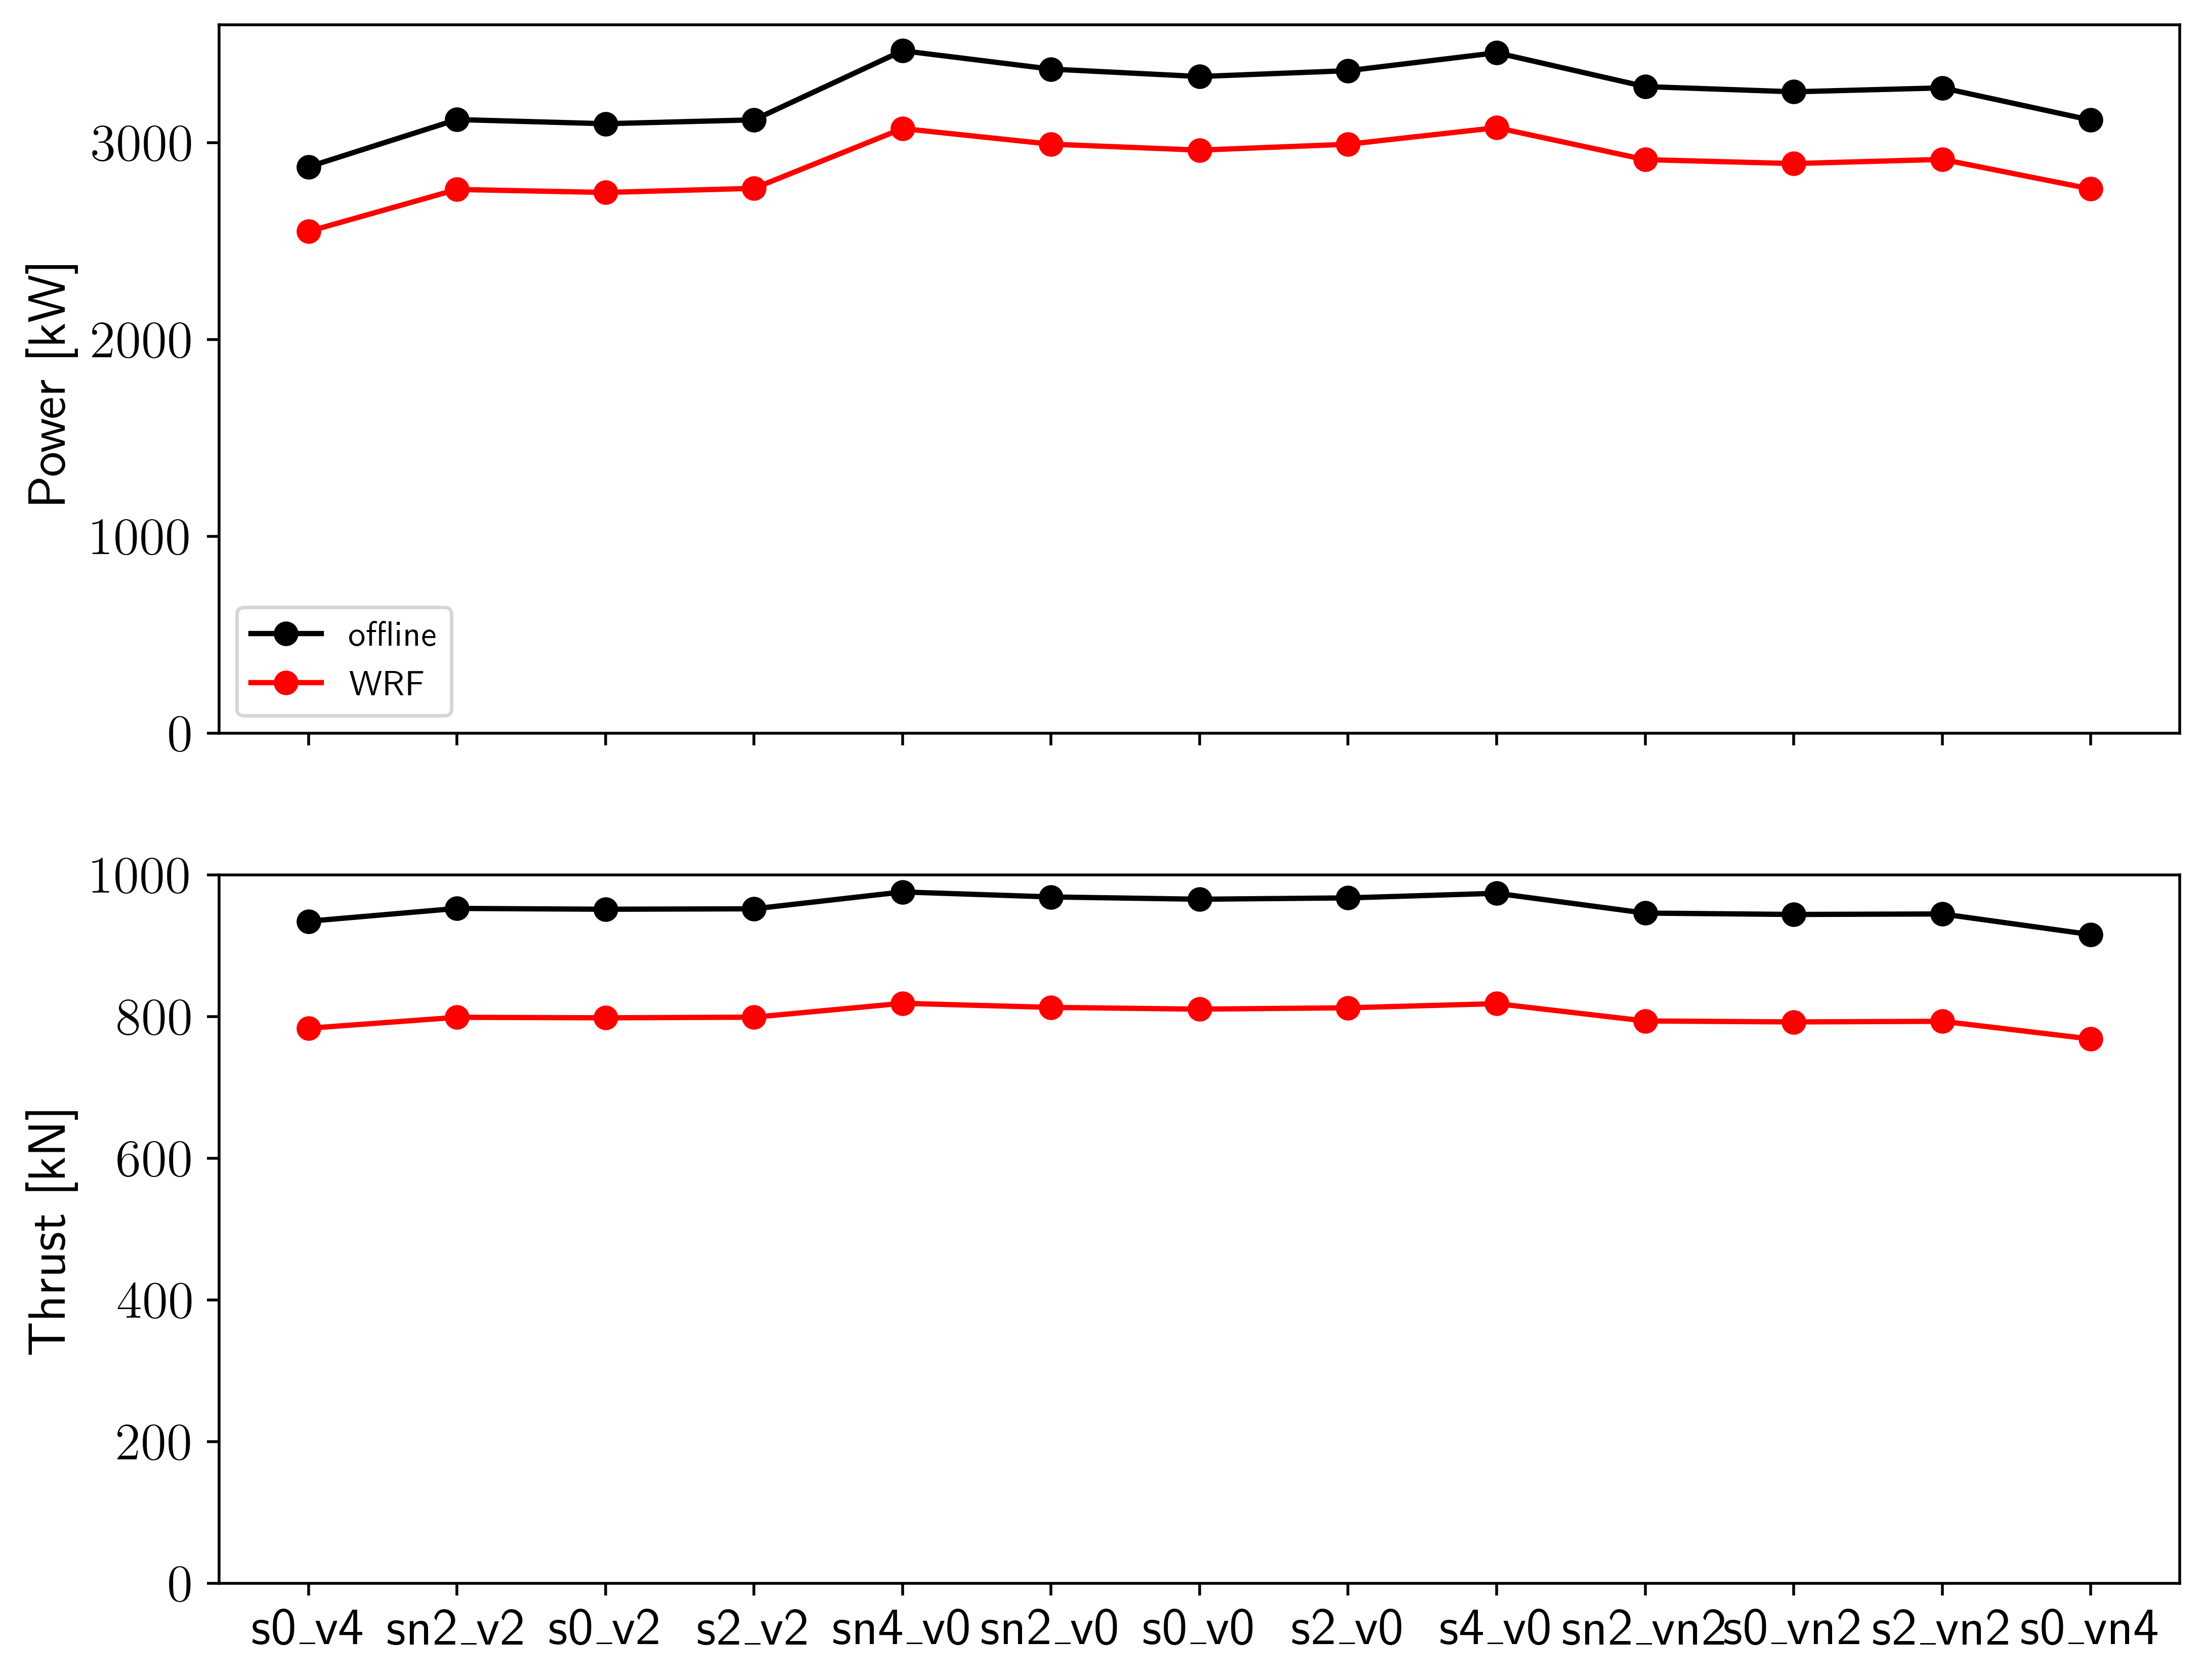

In [68]:

ind = np.arange(len(casenames))

fig, ax = plt.subplots(2,1, figsize=(10, 8), sharex=True)

ax[0].plot(ind,offlinePower, 'o-k', label='offline')
ax[0].plot(ind,power, 'o-r', label='WRF')

ax[1].plot(ind,offlineThrust, 'o-k', label='offline')
ax[1].plot(ind,thrust, 'o-r', label='WRF')


# ax.set_xticks(veers)

ax[0].set_ylim([0, 3600])
ax[1].set_ylim([0, 1000])
ax[1].set_xticks(ind)
ax[1].set_xticklabels(casenames)
ax[0].set_ylabel('Power [kW]', fontsize=15)
ax[1].set_ylabel('Thrust [kN]', fontsize=15)
# ax.set_xlabel('Veer rate [deg/m]', fontsize=15)

ax[0].legend()

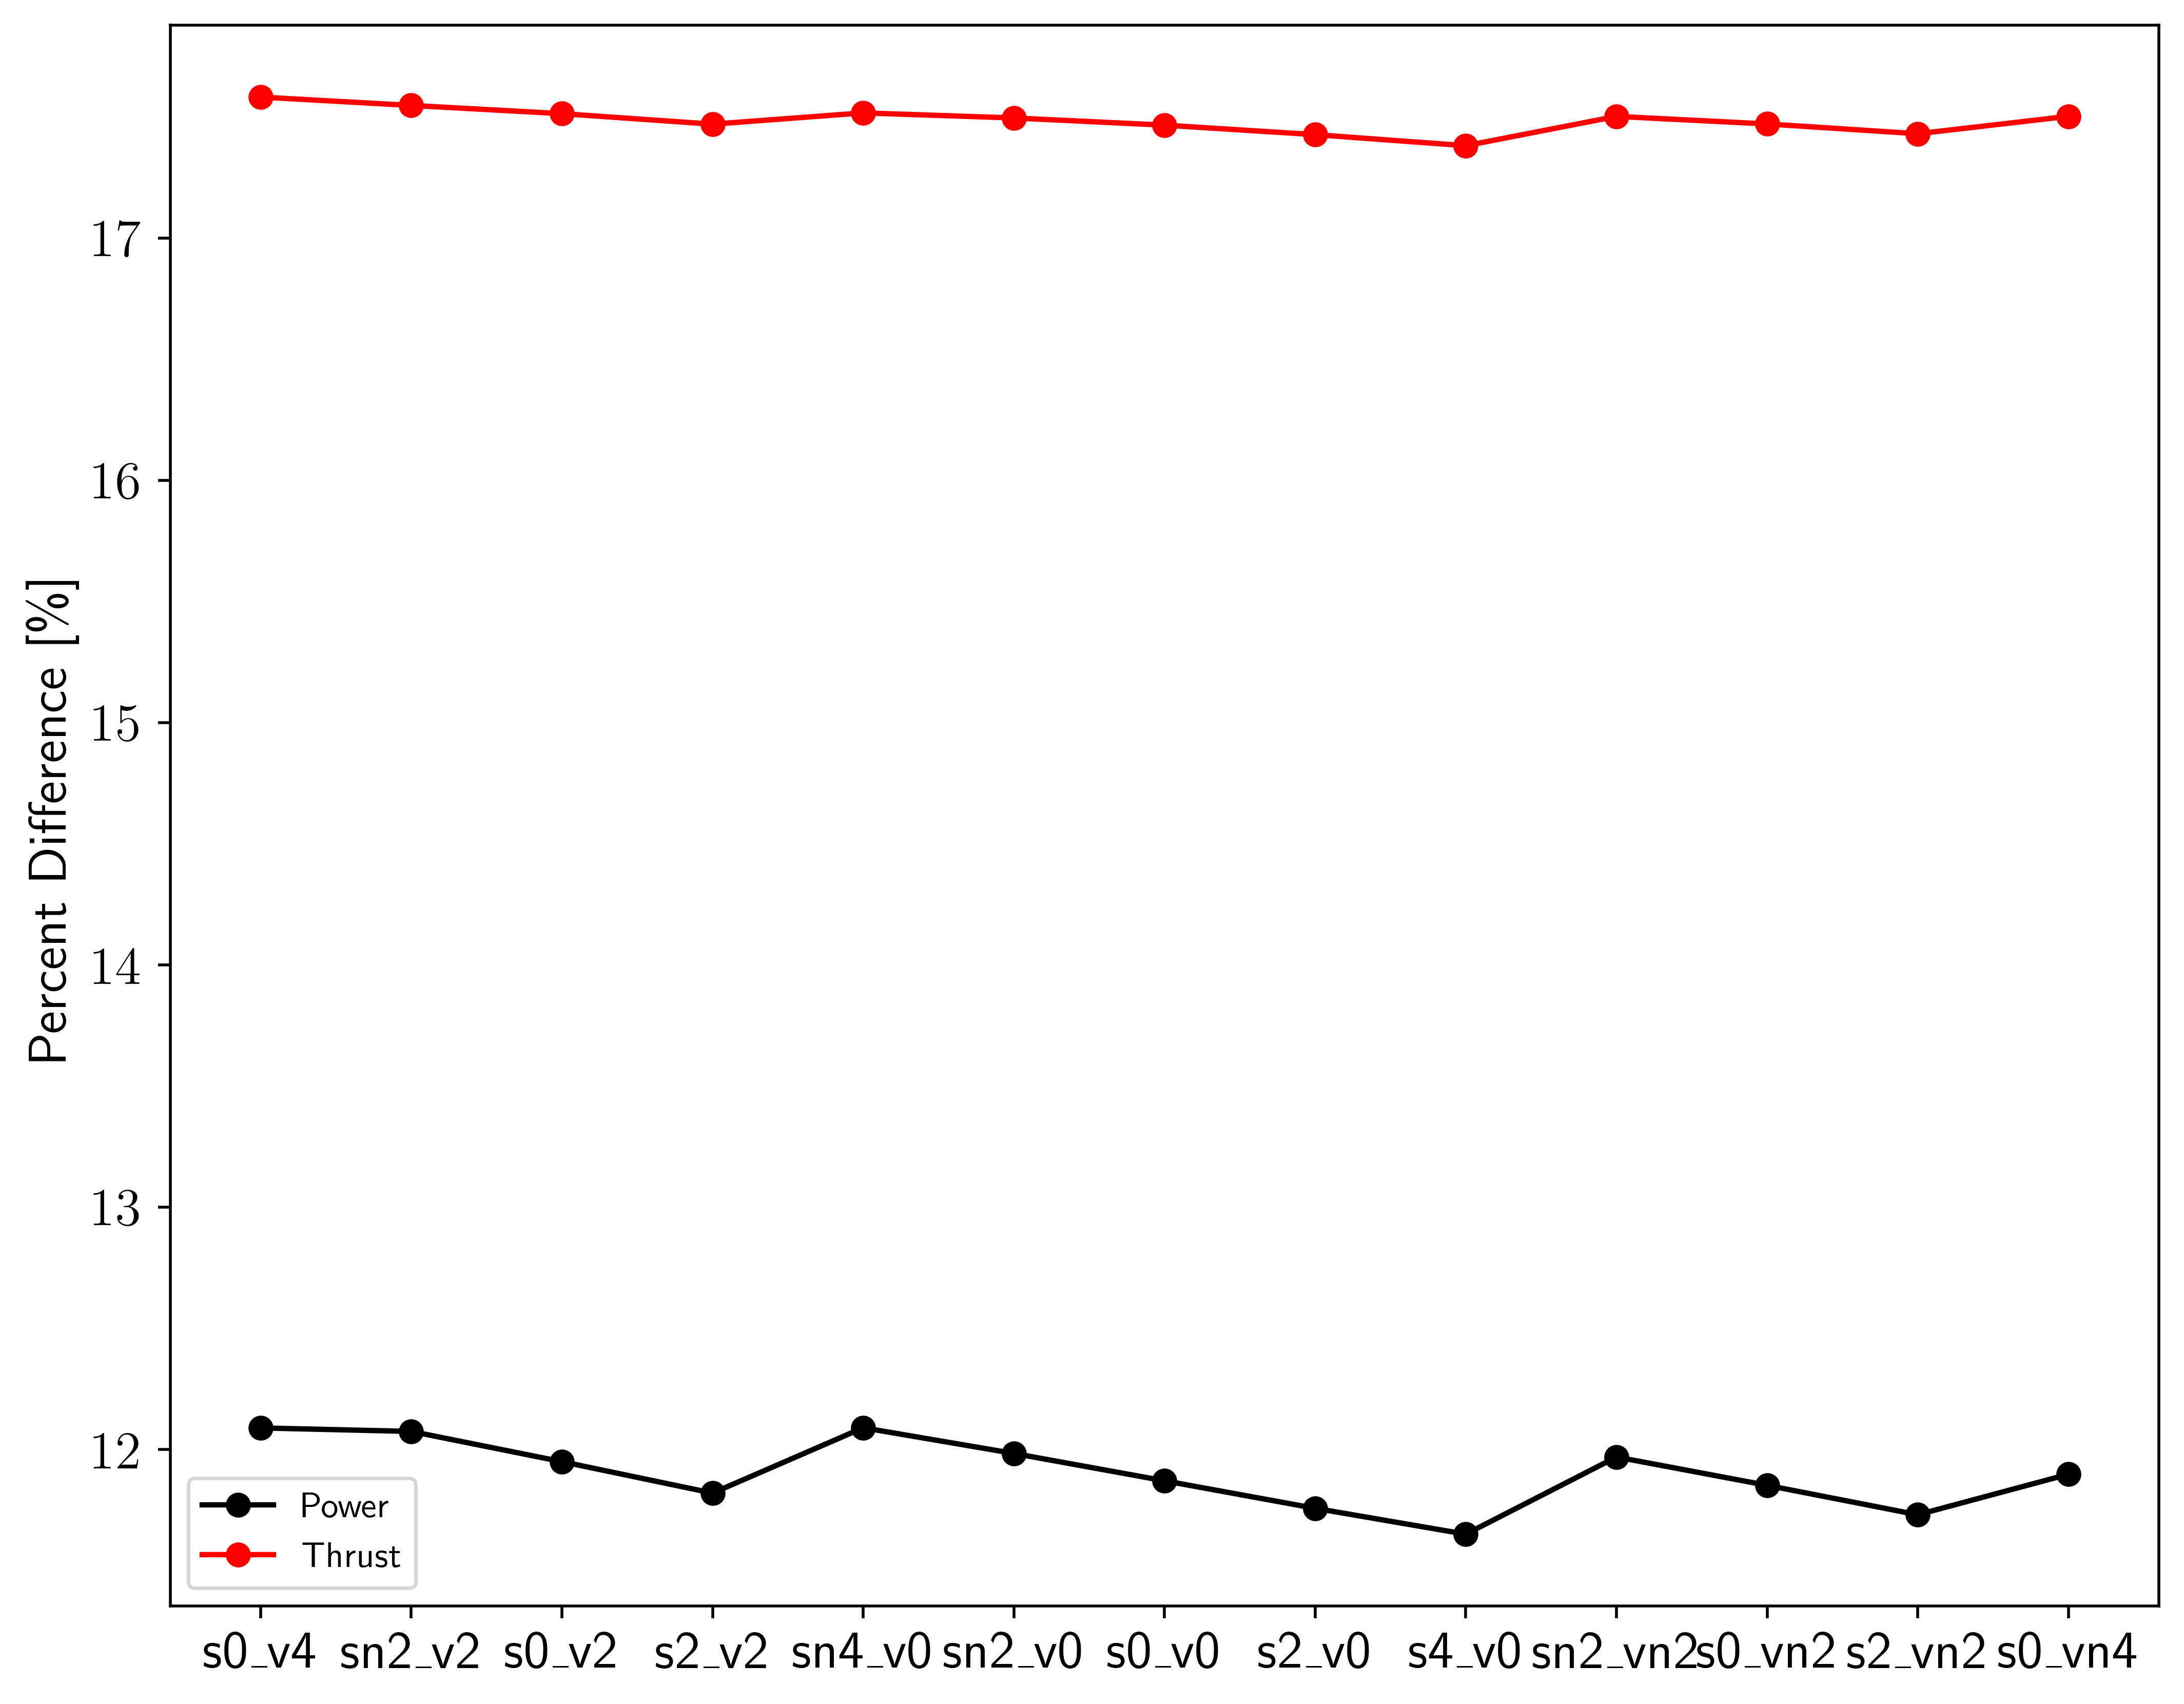

In [78]:

ind = np.arange(len(casenames))

fig, ax = plt.subplots(figsize=(10, 8))

p_err = abs(offlinePower - power) / ((offlinePower + power) / 2) * 100
t_err = abs(offlineThrust - thrust) / ((offlineThrust + thrust)/2) * 100


ax.plot(ind,p_err, 'o-k', label='Power')
ax.plot(ind,t_err, 'o-r', label='Thrust')


# ax.set_xticks(veers)

ax.set_xticks(ind)
ax.set_xticklabels(casenames)
ax.set_ylabel('Percent Difference [\%]', fontsize=15)
# ax.set_xlabel('Veer rate [deg/m]', fontsize=15)

ax.legend()

In [8]:
power_dev     = postproc.per_error(power, power[6])
thrust_dev    = postproc.per_error(thrust, thrust[6])
induction_dev = postproc.per_error(induction, induction[6])

In [9]:
n_levels = 100

pow_levels = plt.colormaps['seismic'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-15, vmax=15)  # Normalize power to [0, 1]
pow_cmap = [pow_levels(int(norm(p) * (n_levels - 1))) for p in power_dev]  # Map power to discrete colors

thr_levels = plt.colormaps['PiYG'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-6, vmax=6)  # Normalize power to [0, 1]
thr_cmap = [thr_levels(int(norm(t) * (n_levels - 1))) for t in thrust_dev]  # Map power to discrete colors

ind_levels = plt.colormaps['Spectral'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-13, vmax=13)  # Normalize power to [0, 1]
ind_cmap = [ind_levels(int(norm(a) * (n_levels - 1))) for a in induction_dev]  # Map power to discrete colors

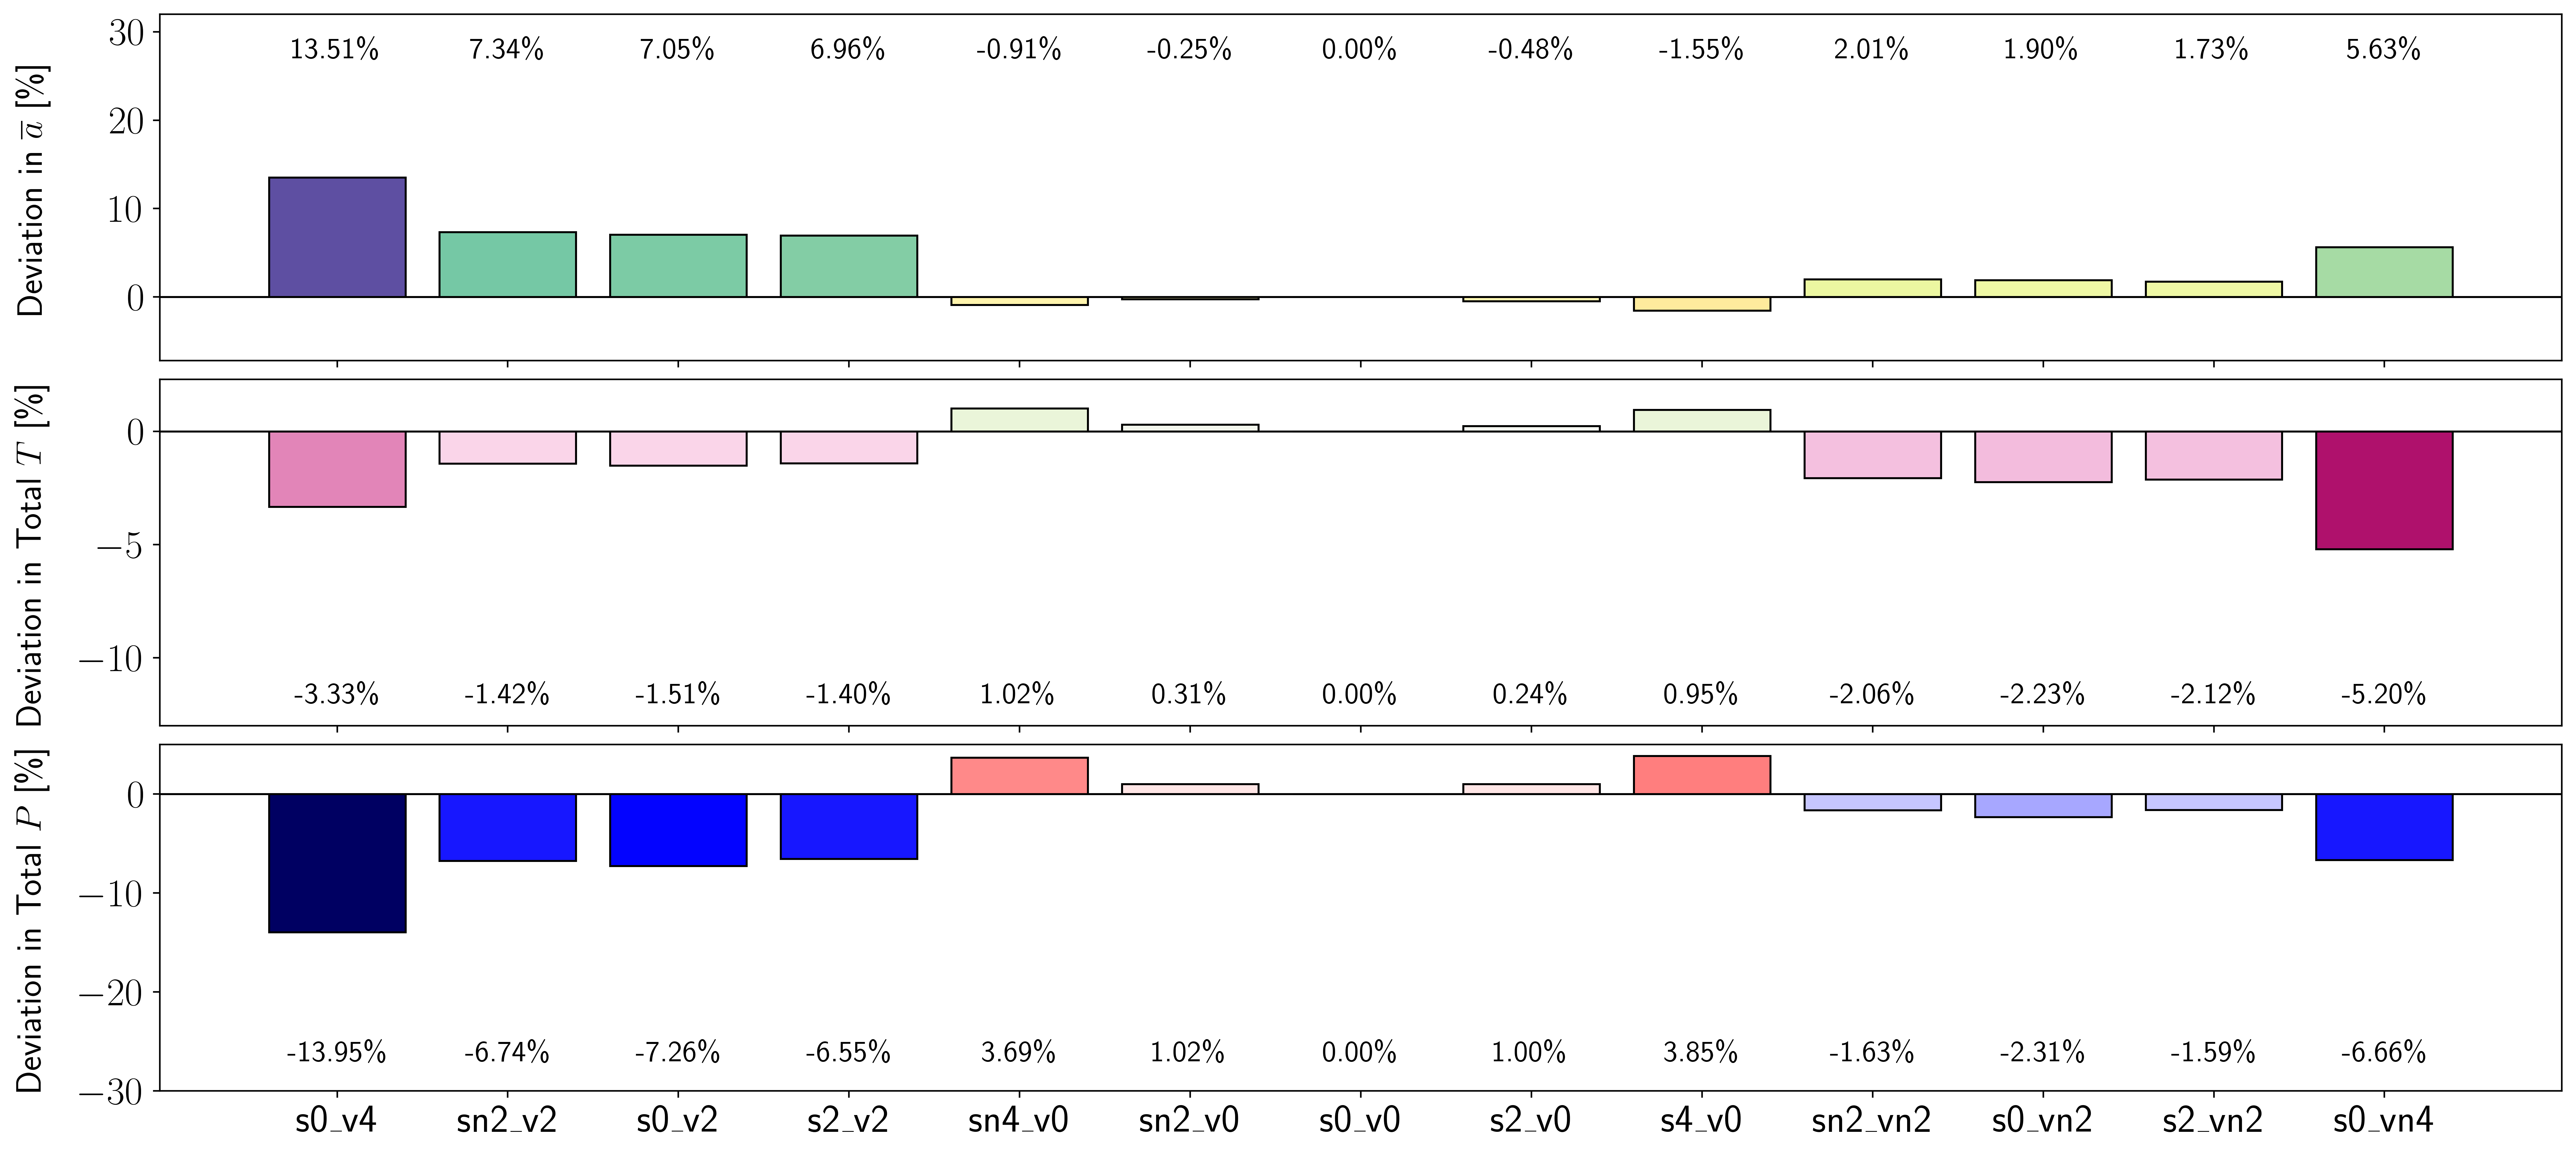

In [81]:
width = 0.75
alpha = 1.0

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, constrained_layout = True)
ax[0].axhline(0, color='black', linestyle='solid', linewidth=1)
ax[1].axhline(0, color='black', linestyle='solid', linewidth=1)
ax[2].axhline(0, color='black', linestyle='solid', linewidth=1)

ind = np.arange(len(casenames))

for count in range(len(casenames)):

    # induction
    ax[0].bar(ind[count], induction_dev[count], color=ind_cmap[count], edgecolor='black', alpha=alpha)
    ax[0].set_ylabel(r'Deviation in ${\overline{a}}$ [\%]', fontsize=fontsize*0.75, labelpad=30)
    ax[0].text(ind[count], 27, f'{induction_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[0].set_ylim([-7.2,32])

    # thrust
    ax[1].bar(ind[count], thrust_dev[count], color=thr_cmap[count], edgecolor='black', alpha=alpha)
    ax[1].set_ylabel(r'Deviation in Total $T$ [\%]', fontsize=fontsize*0.75, labelpad=15)
    ax[1].text(ind[count], -12, f'{thrust_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[1].set_ylim([-13,2.3])

    # power
    ax[2].bar(ind[count], power_dev[count], color=pow_cmap[count], edgecolor='black', alpha=alpha)
    ax[2].set_xticks(ind)
    ax[2].set_xticklabels(casenames)
    ax[2].set_ylabel(r'Deviation in Total $P$ [\%]', fontsize=fontsize*0.75, labelpad=15)
    ax[2].text(ind[count], -27, f'{power_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[2].set_ylim([-30,5])

# plt.savefig("/scratch/09909/smata/wrf_les_sweep/runs/clockwise/gad_sweep/figs/rel_err_ind_thrust_torque_power.png", bbox_inches="tight", dpi=800)
plt.show()

In [82]:
n_levels = 100

power_int = np.max(np.abs([power - power[6]]))
p_min = np.max(np.abs(power[6] - power_int))/1000
p_max = np.max(np.abs(power[6] + power_int))/1000

thrust_int = np.max(np.abs([thrust - thrust[6]]))
t_min = np.max(np.abs(thrust[6] - thrust_int))/1000
t_max = np.max(np.abs(thrust[6] + thrust_int))/1000

induction_int = np.max(np.abs([induction - induction[6]]))
a_min = np.max(np.abs(induction[6] - induction_int))
a_max = np.max(np.abs(induction[6] + induction_int))

pow_levels = plt.colormaps['seismic'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=p_min, vmax=p_max)  # Normalize power to [0, 1]
pow_cmap = [pow_levels(int(norm(p) * (n_levels - 1))) for p in power/1000]  # Map power to discrete colors

thr_levels = plt.colormaps['PiYG'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=t_min, vmax=t_max)  # Normalize power to [0, 1]
thr_cmap = [thr_levels(int(norm(t) * (n_levels - 1))) for t in thrust/1000]  # Map power to discrete colors

ind_levels = plt.colormaps['BrBG'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=a_min, vmax=a_max)  # Normalize power to [0, 1]
ind_cmap = [ind_levels(int(norm(a) * (n_levels - 1))) for a in induction]  # Map power to discrete colors

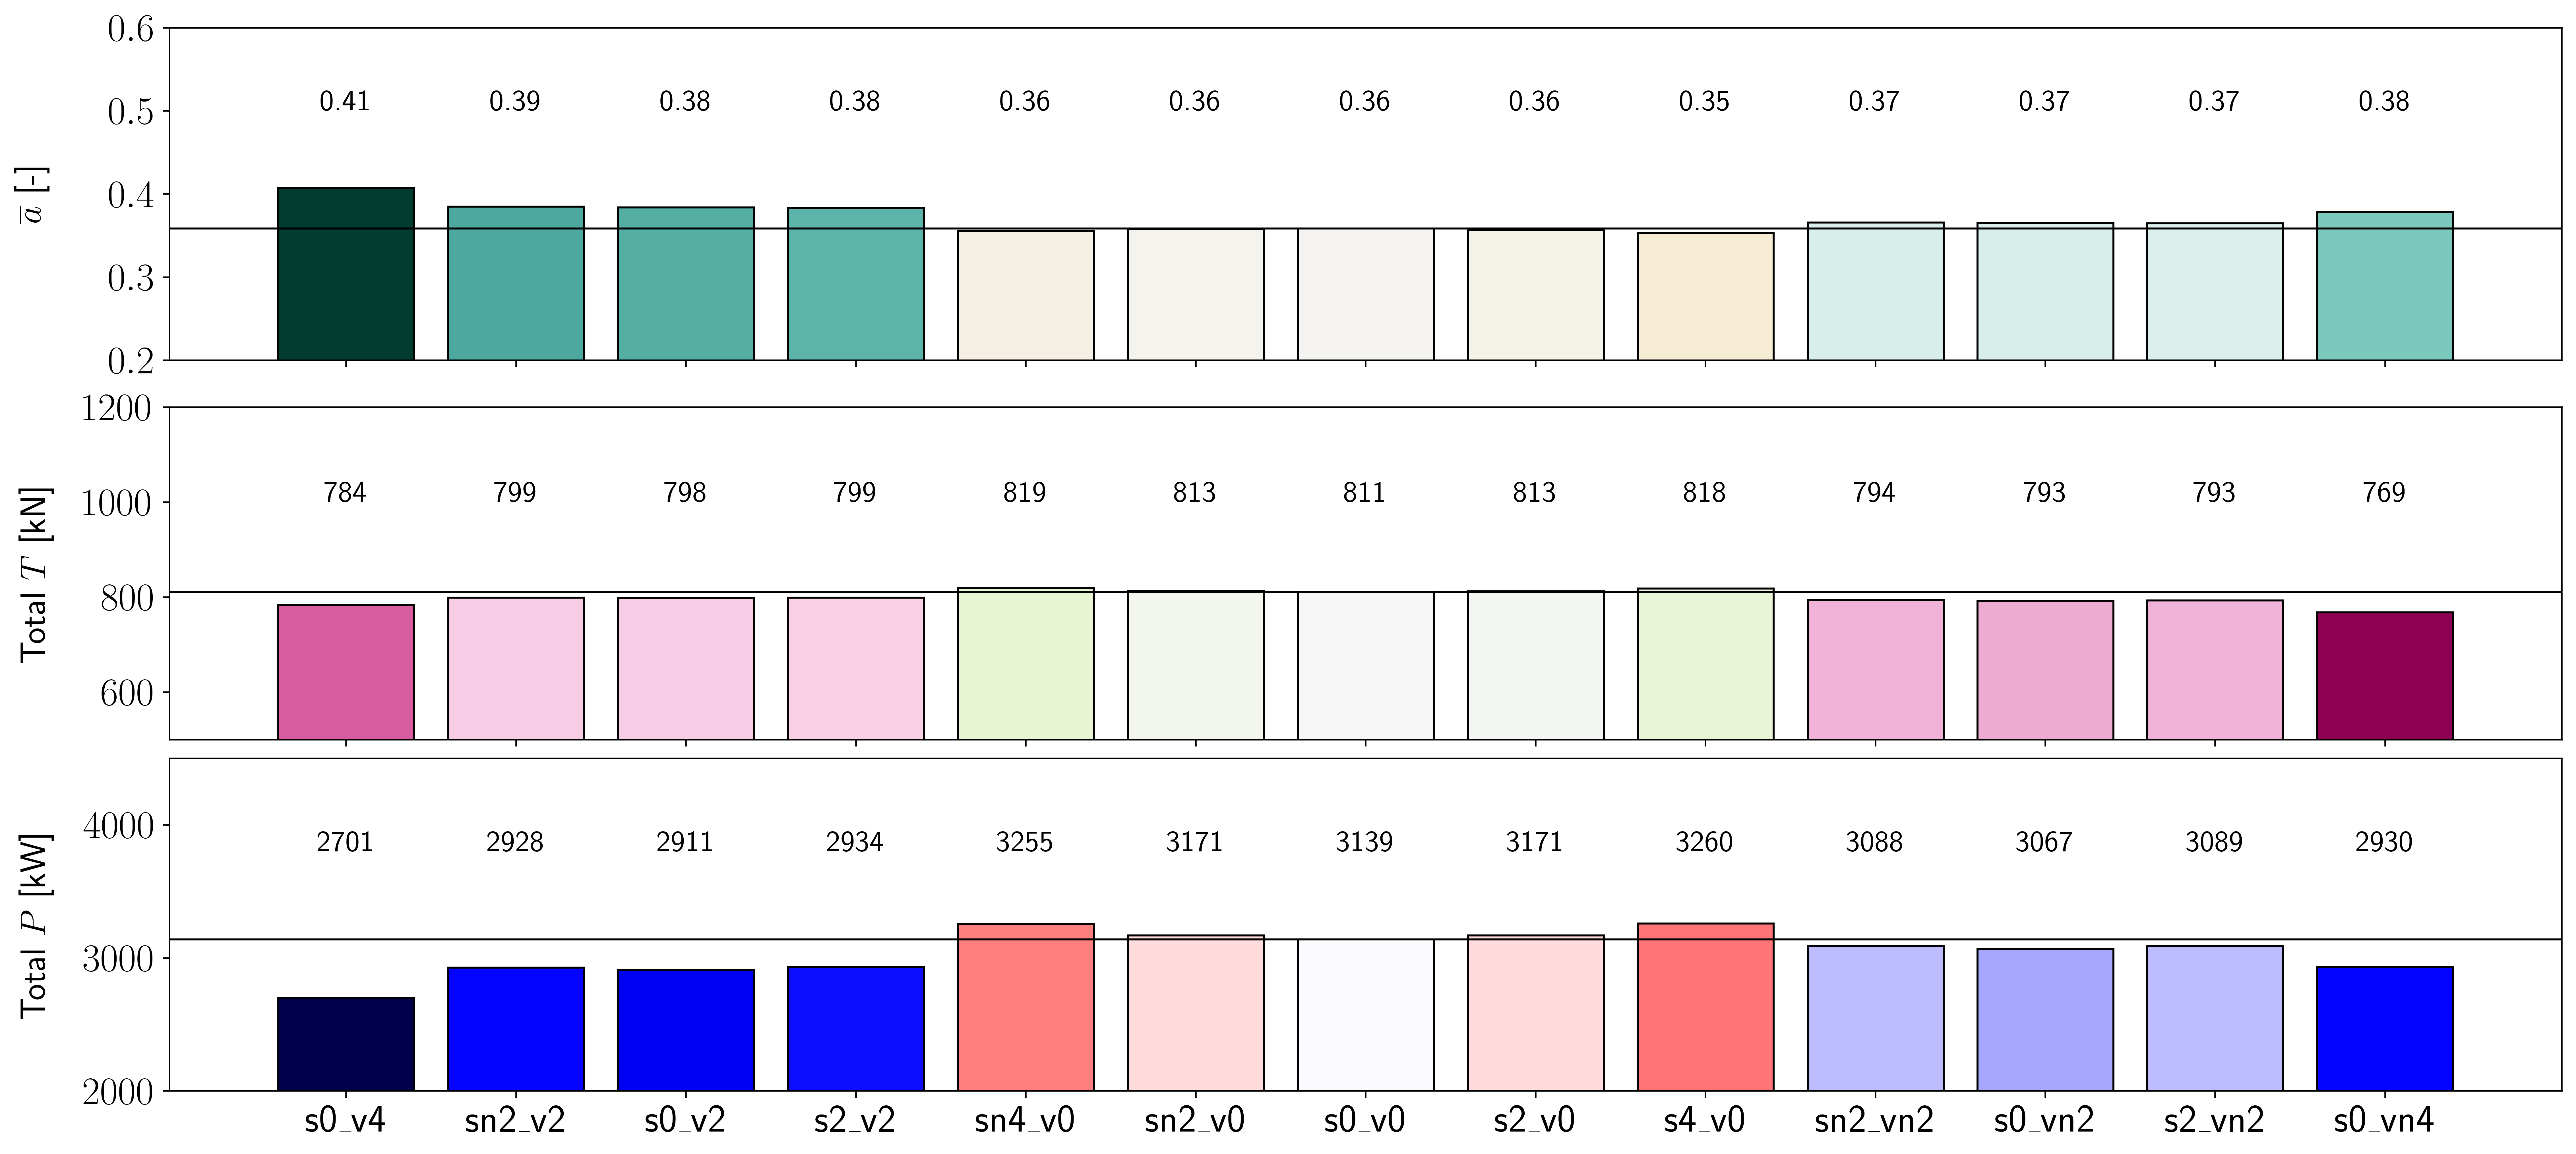

In [83]:
width = 0.75
alpha = 1.0

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, constrained_layout = True)
ax[0].axhline(induction[6], color='black', linestyle='solid', linewidth=1)
ax[1].axhline(thrust[6]/1000, color='black', linestyle='solid', linewidth=1)
ax[2].axhline(power[6]/1000, color='black', linestyle='solid', linewidth=1)

ind = np.arange(len(casenames))

for count in range(len(casenames)):

    # induction
    ax[0].bar(ind[count], induction[count], color=ind_cmap[count], edgecolor='black', alpha=alpha)
    ax[0].set_ylabel(r'${\overline{a}}$ [-]', fontsize=fontsize*0.75, labelpad=30)
    ax[0].text(ind[count], 0.5, f'{induction[count]:0.2f}', ha='center', fontsize=15)
    ax[0].set_ylim([0.2,0.6])

    # thrust
    ax[1].bar(ind[count], thrust[count]/1000, color=thr_cmap[count], edgecolor='black', alpha=alpha)
    ax[1].set_ylabel(r'Total $T$ [kN]', fontsize=fontsize*0.75, labelpad=15)
    ax[1].text(ind[count], 1000, f'{thrust[count]/1000:0.0f}', ha='center', fontsize=15)
    ax[1].set_ylim([500,1200])

    # power
    ax[2].bar(ind[count], power[count]/1000, color=pow_cmap[count], edgecolor='black', alpha=alpha)
    ax[2].set_xticks(ind)
    ax[2].set_xticklabels(casenames)
    ax[2].set_ylabel(r'Total $P$ [kW]', fontsize=fontsize*0.75, labelpad=15)
    ax[2].text(ind[count], 3800, f'{power[count]/1000:0.0f}', ha='center', fontsize=15)
    ax[2].set_ylim([2000,4500])

# plt.savefig("/scratch/09909/smata/wrf_les_sweep/runs/clockwise/gad_sweep/figs/rel_err_ind_thrust_torque_power.png", bbox_inches="tight", dpi=800)
plt.show()

In [ ]:
# clockwise wrf
# induction_dev = [14.3,7.4,7.0,5.8,-0.5,0.4,0.0,-1.5,-3.6,0.8,0.4,-0.9,3.0]
# thrust_dev = [-1.7,-0.7,-0.7,-0.6,0.6,0.1,0.0,0.2,0.7,-1.5,-1.6,-1.5,-3.7]
# power_dev = [-10.5,-5,-5.4,-4.6,2.7,0.5,0.0,1.1,3.3,-0.4,-0.9,-0.0,-3.3]

#counter clockwise wrf
# induction_dev = [3.0,0.8,0.4,-0.9,-0.5,0.3,0.0,-1.4,-3.6,7.4,6.9,5.8,14.2]
# thrust_dev = [-3.7,-1.5,-1.6,-1.5,0.6,0.1,0.0,0.2,0.7,-0.7,-0.7,-0.6,-1.7]
# power_dev = [-3.4,-0.4,-0.9,-0.0,2.7,0.6,0.0,1.1,3.4,-5.0,-5.3,-4.7,-10.5]

wrf_ind = np.array([14.15,7.48,7.65,7.37,-1.67,-1.35,0.00,0.08,-0.99,2.59,2.20,1.17,4.78])
wrf_thrust = np.array([-3.33,-1.42,-1.51,-1.40,1.02,0.31,0.00,0.24,0.95,-2.06,-2.23,-2.12,-5.20])
wrf_power = np.array([-13.95,-6.74,-7.26,-6.55,3.69,1.02,0.00,1.00,3.85,-1.63,-2.31,-1.59,-6.66])

# classical closure
# induction_dev = np.array([3.25,1.71,1.67,1.62,0.06,0.03,0.00,-0.05,-0.11,-1.64,-1.67,-1.72,-3.23])
# thrust_dev = np.array([1.23,0.66,0.65,0.63,0.02,0.01,0.00,-0.02,-0.04,-0.66,-0.68,-0.70,-1.34])
# power_dev = np.array([-3.27,-1.52,-1.69,-1.61,0.60,0.17,0.00,0.08,0.42,1.87,1.69,1.77,3.32])

# wrf closure
# induction_dev = [14.15,7.48,7.65,7.37,-1.67,-1.35,0.00,0.08,-0.99,2.59,2.20,1.17,4.78]
# thrust_dev = [-3.09,-1.32,-1.40,-1.26,0.84,0.24,0.00,0.24,0.89,-2.06,-2.18,-2.04,-4.94]
# power_dev = [-14.07,-6.78,-7.42,-6.73,3.88,1.10,0.00,0.97,3.80,-1.42,-2.18,-1.49,-6.25]

# Madsen annulus closure
induction_dev = [20.90, 10.40, 10.38, 10.34, 0.04, 0.03, 0.00, -0.04, -0.10, 7.46, 7.44, 7.40, 15.60]
thrust_dev = [-4.13, -1.84, -1.85, -1.88, 0.02, 0.01, 0.00, -0.02, -0.06, -3.64, -3.65, -3.67, -7.34]
power_dev = [-17.52, -8.59, -8.75, -8.69, 0.62, 0.18, 0.00, 0.07, 0.40, -6.47, -6.64, -6.58, -13.75]

induction_dev = induction_dev - wrf_ind
thrust_dev = thrust_dev - wrf_thrust
power_dev = power_dev - wrf_power

casenames = [r's0_v4', r'sn2_v2', r's0_v2',r's2_v2', r'sn4_v0', r'sn2_v0', r's0_v0', r's2_v0', r's4_v0', r'sn2_vn2', r's0_vn2', r's2_vn2', r's0_vn4']


In [17]:
n_levels = 100

pow_levels = plt.colormaps['seismic'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-15, vmax=15)  # Normalize power to [0, 1]
pow_cmap = [pow_levels(int(norm(p) * (n_levels - 1))) for p in power_dev]  # Map power to discrete colors

thr_levels = plt.colormaps['PiYG'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-6, vmax=6)  # Normalize power to [0, 1]
thr_cmap = [thr_levels(int(norm(t) * (n_levels - 1))) for t in thrust_dev]  # Map power to discrete colors

ind_levels = plt.colormaps['Spectral'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-13, vmax=13)  # Normalize power to [0, 1]
ind_cmap = [ind_levels(int(norm(a) * (n_levels - 1))) for a in induction_dev]  # Map power to discrete colors



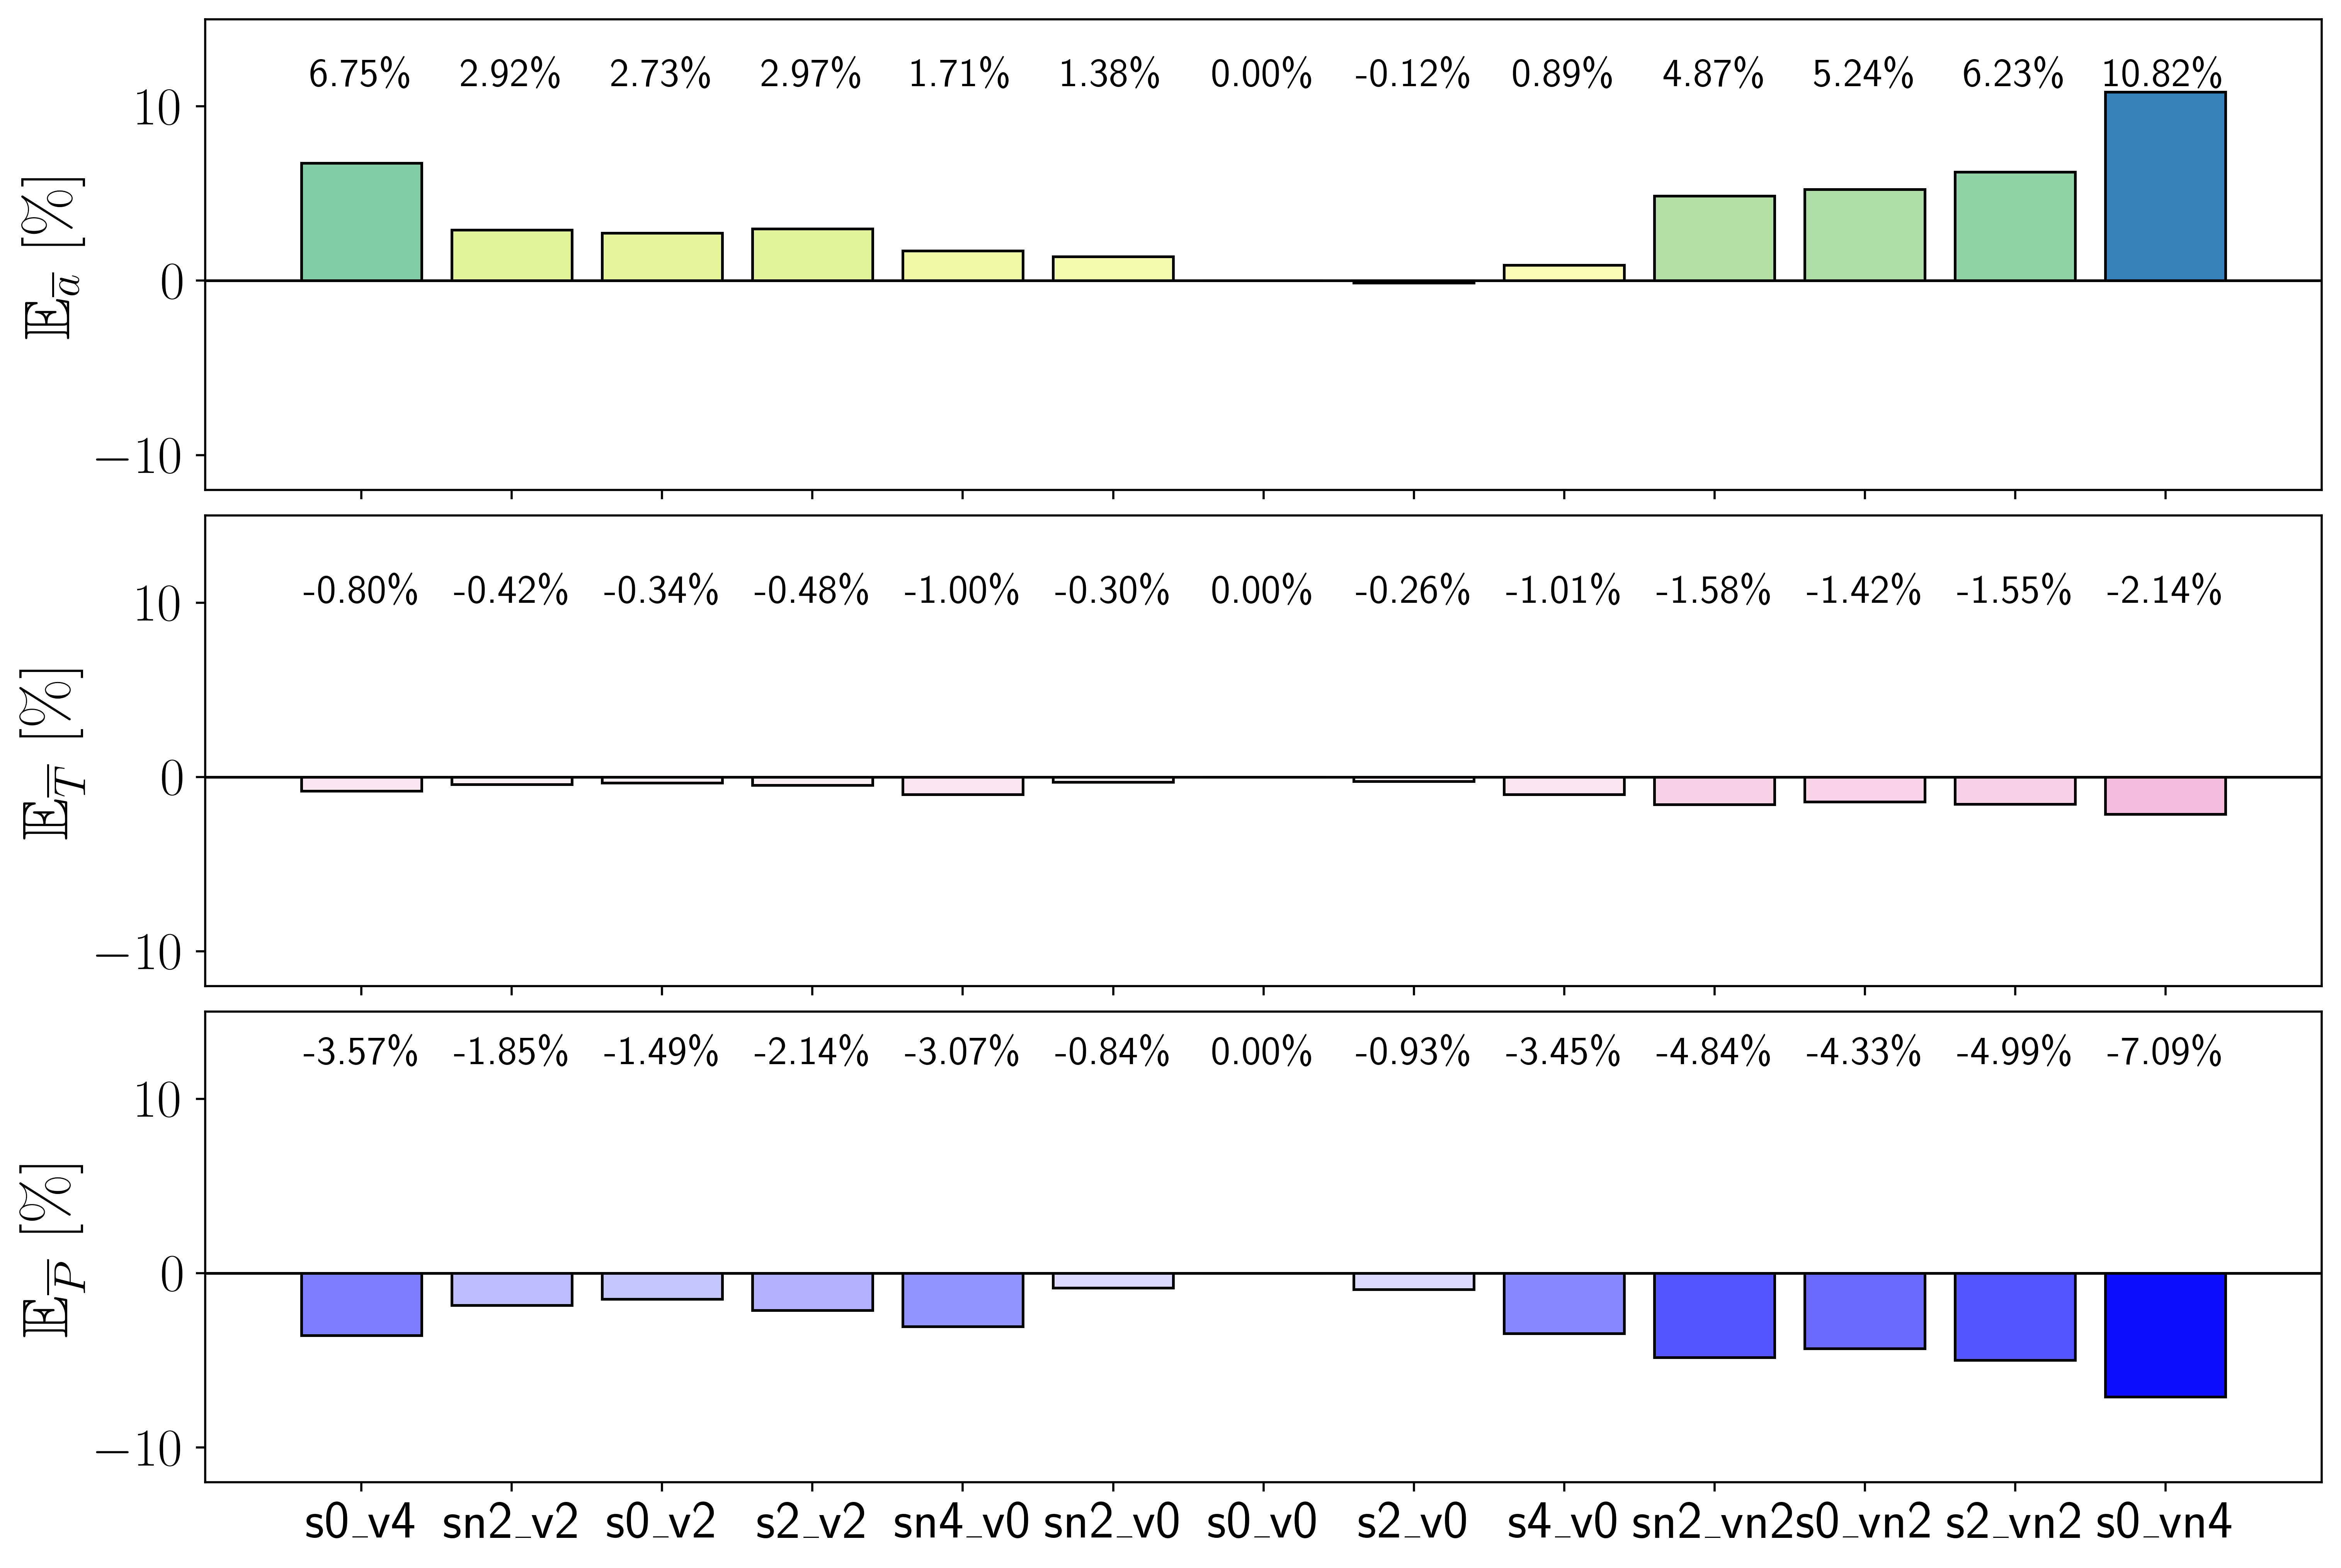

In [20]:

width = 0.75
alpha = 1.0

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 8), sharex=True, constrained_layout = True)
ax[0].axhline(0, color='black', linestyle='solid', linewidth=1)
ax[1].axhline(0, color='black', linestyle='solid', linewidth=1)
ax[2].axhline(0, color='black', linestyle='solid', linewidth=1)

ind = np.arange(len(casenames))

for count in range(len(casenames)):

    # induction
    ax[0].bar(ind[count], induction_dev[count], color=ind_cmap[count], edgecolor='black', alpha=alpha)
    # ax[0].set_ylabel(r'Deviation in ${\overline{a}}$ [\%]', fontsize=fontsize*0.75, labelpad=30)
    ax[0].set_ylabel(r'$\mathrm{\mathbb{E}}_{\overline{a}}~[\%]$', fontsize=fontsize)
    ax[0].text(ind[count], 11.15, f'{induction_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[0].set_ylim([-12,15])

    # thrust
    ax[1].bar(ind[count], thrust_dev[count], color=thr_cmap[count], edgecolor='black', alpha=alpha)
    # ax[1].set_ylabel(r'Deviation in Total $T$ [\%]', fontsize=fontsize*0.75, labelpad=15)
    ax[1].set_ylabel(r'$\mathrm{\mathbb{E}}_{\overline{T}}~[\%]$', fontsize=fontsize)
    ax[1].text(ind[count], 10, f'{thrust_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[1].set_ylim([-12,15])

    # power
    ax[2].bar(ind[count], power_dev[count], color=pow_cmap[count], edgecolor='black', alpha=alpha)
    ax[2].set_xticks(ind)
    ax[2].set_xticklabels(casenames)
    # ax[2].set_ylabel(r'Deviation in Total $P$ [\%]', fontsize=fontsize*0.75, labelpad=15)
    ax[2].set_ylabel(r'$\mathrm{\mathbb{E}}_{\overline{P}}~[\%]$', fontsize=fontsize)
    ax[2].text(ind[count], 12, f'{power_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[2].set_ylim([-12,15])

# plt.savefig("/scratch/09909/smata/wrf_les_sweep/runs/clockwise/gad_sweep/figs/rel_err_ind_thrust_torque_power.png", bbox_inches="tight", dpi=800)
plt.show()

In [8]:
casenames = [r's0_v4', r'sn2_v2', r's0_v2',r's2_v2', r'sn4_v0', r'sn2_v0', r's0_v0', r's2_v0', r's4_v0', r'sn2_vn2', r's0_vn2', r's2_vn2', r's0_vn4']

casenames = [r's0_v4', r's0_v2', r's0_v0',r's0_vn2',r's0_vn4']

v_inds = [0,2,6,10,12]

veernames = ['-0.4','0.2','0.0','0.2','0.4']
veers = [-0.4,-0.2,0.0,0.2,0.4]

veers_mit = np.arange(-4,4.25,0.25)/10

In [24]:
# madsen = np.array([0.45310412, 0.50074523, 0.49982093, 0.50016807, 0.54736666,
#        0.5449814 , 0.54397761, 0.54436565, 0.54615579, 0.51215169,
#        0.51120569, 0.51156072, 0.47381353])

madsen = np.array([0.51178121, 0.51103054, 0.51027809, 0.50952105, 0.50876649,
       0.50800509, 0.50724657, 0.50648552, 0.50572525, 0.50496118,
       0.50419568, 0.50342994, 0.50266333, 0.50189386, 0.50112601,
       0.50035775, 0.49959052, 0.49882426, 0.49805899, 0.49729636,
       0.49653507, 0.49578009, 0.49503009, 0.49428505, 0.49354755,
       0.4928209 , 0.49210063, 0.49139243, 0.49069067, 0.49000626,
       0.48933056, 0.4886705 , 0.48802439])

# classical = np.array([0.50082847, 0.50987928, 0.50900215, 0.50942007, 0.52086116,
#        0.5186582 , 0.51776236, 0.51818118, 0.51992354, 0.52744682,
#        0.52653228, 0.52695186, 0.53495949])

classical = np.array([0.53495949, 0.53393257, 0.53289717, 0.53185137, 0.53080242,
       0.52973984, 0.52867721, 0.52760559, 0.52653229, 0.52544934,
       0.52436078, 0.52326928, 0.52217404, 0.5210731 , 0.51997128,
       0.51886756, 0.51776236, 0.51665739, 0.51555347, 0.51445081,
       0.51334818, 0.51225301, 0.51116419, 0.51007933, 0.50900214,
       0.5079396 , 0.50688256, 0.50583946, 0.50480439, 0.50378847,
       0.50278451, 0.50179844, 0.50082847])

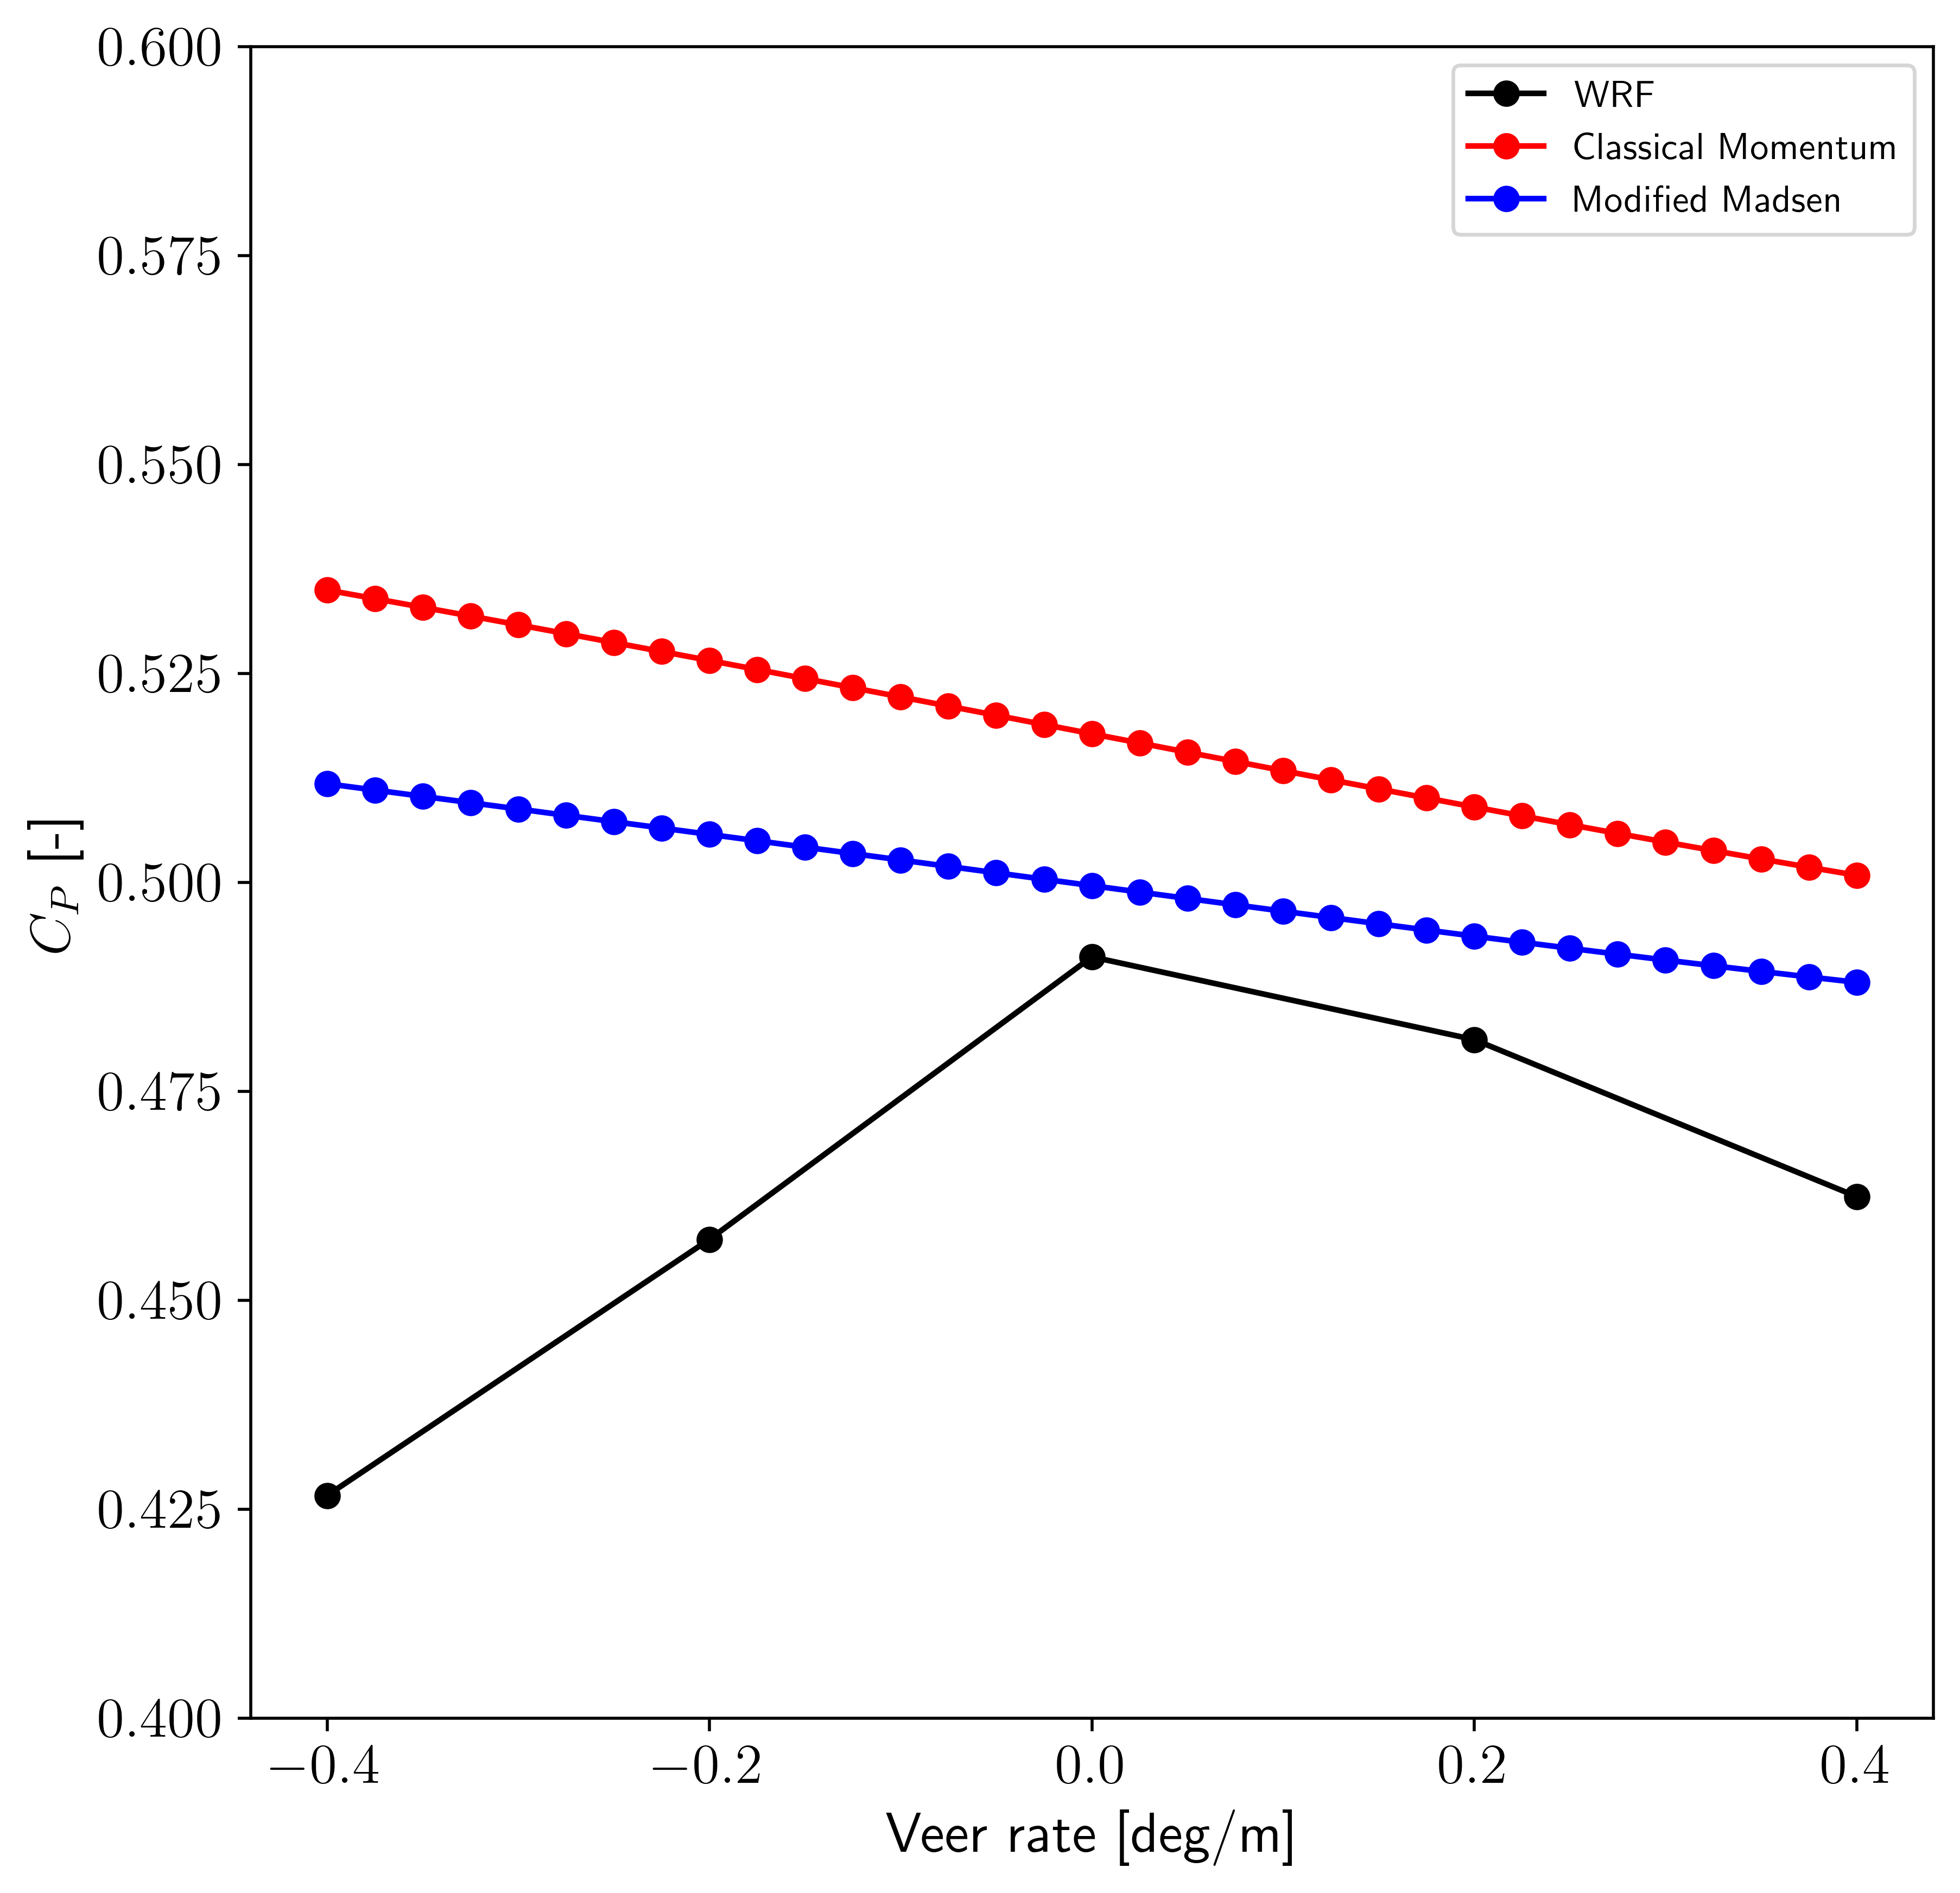

In [25]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(veers,cp[v_inds], 'o-k', label='WRF')
# ax.plot(veers,classical[v_inds], 'o-r', label='Classical Momentum')
ax.plot(veers_mit,classical, 'o-r', label='Classical Momentum',zorder=3)

# ax.plot(veers,madsen[v_inds], 'o-b', label='Modified Madsen')
ax.plot(veers_mit,madsen, 'o-b', label='Modified Madsen')


ax.set_xticks(veers)

ax.set_ylim([0.40, 0.60])
ax.set_ylabel('$C_P$ [-]', fontsize=15)
ax.set_xlabel('Veer rate [deg/m]', fontsize=15)

ax.legend()

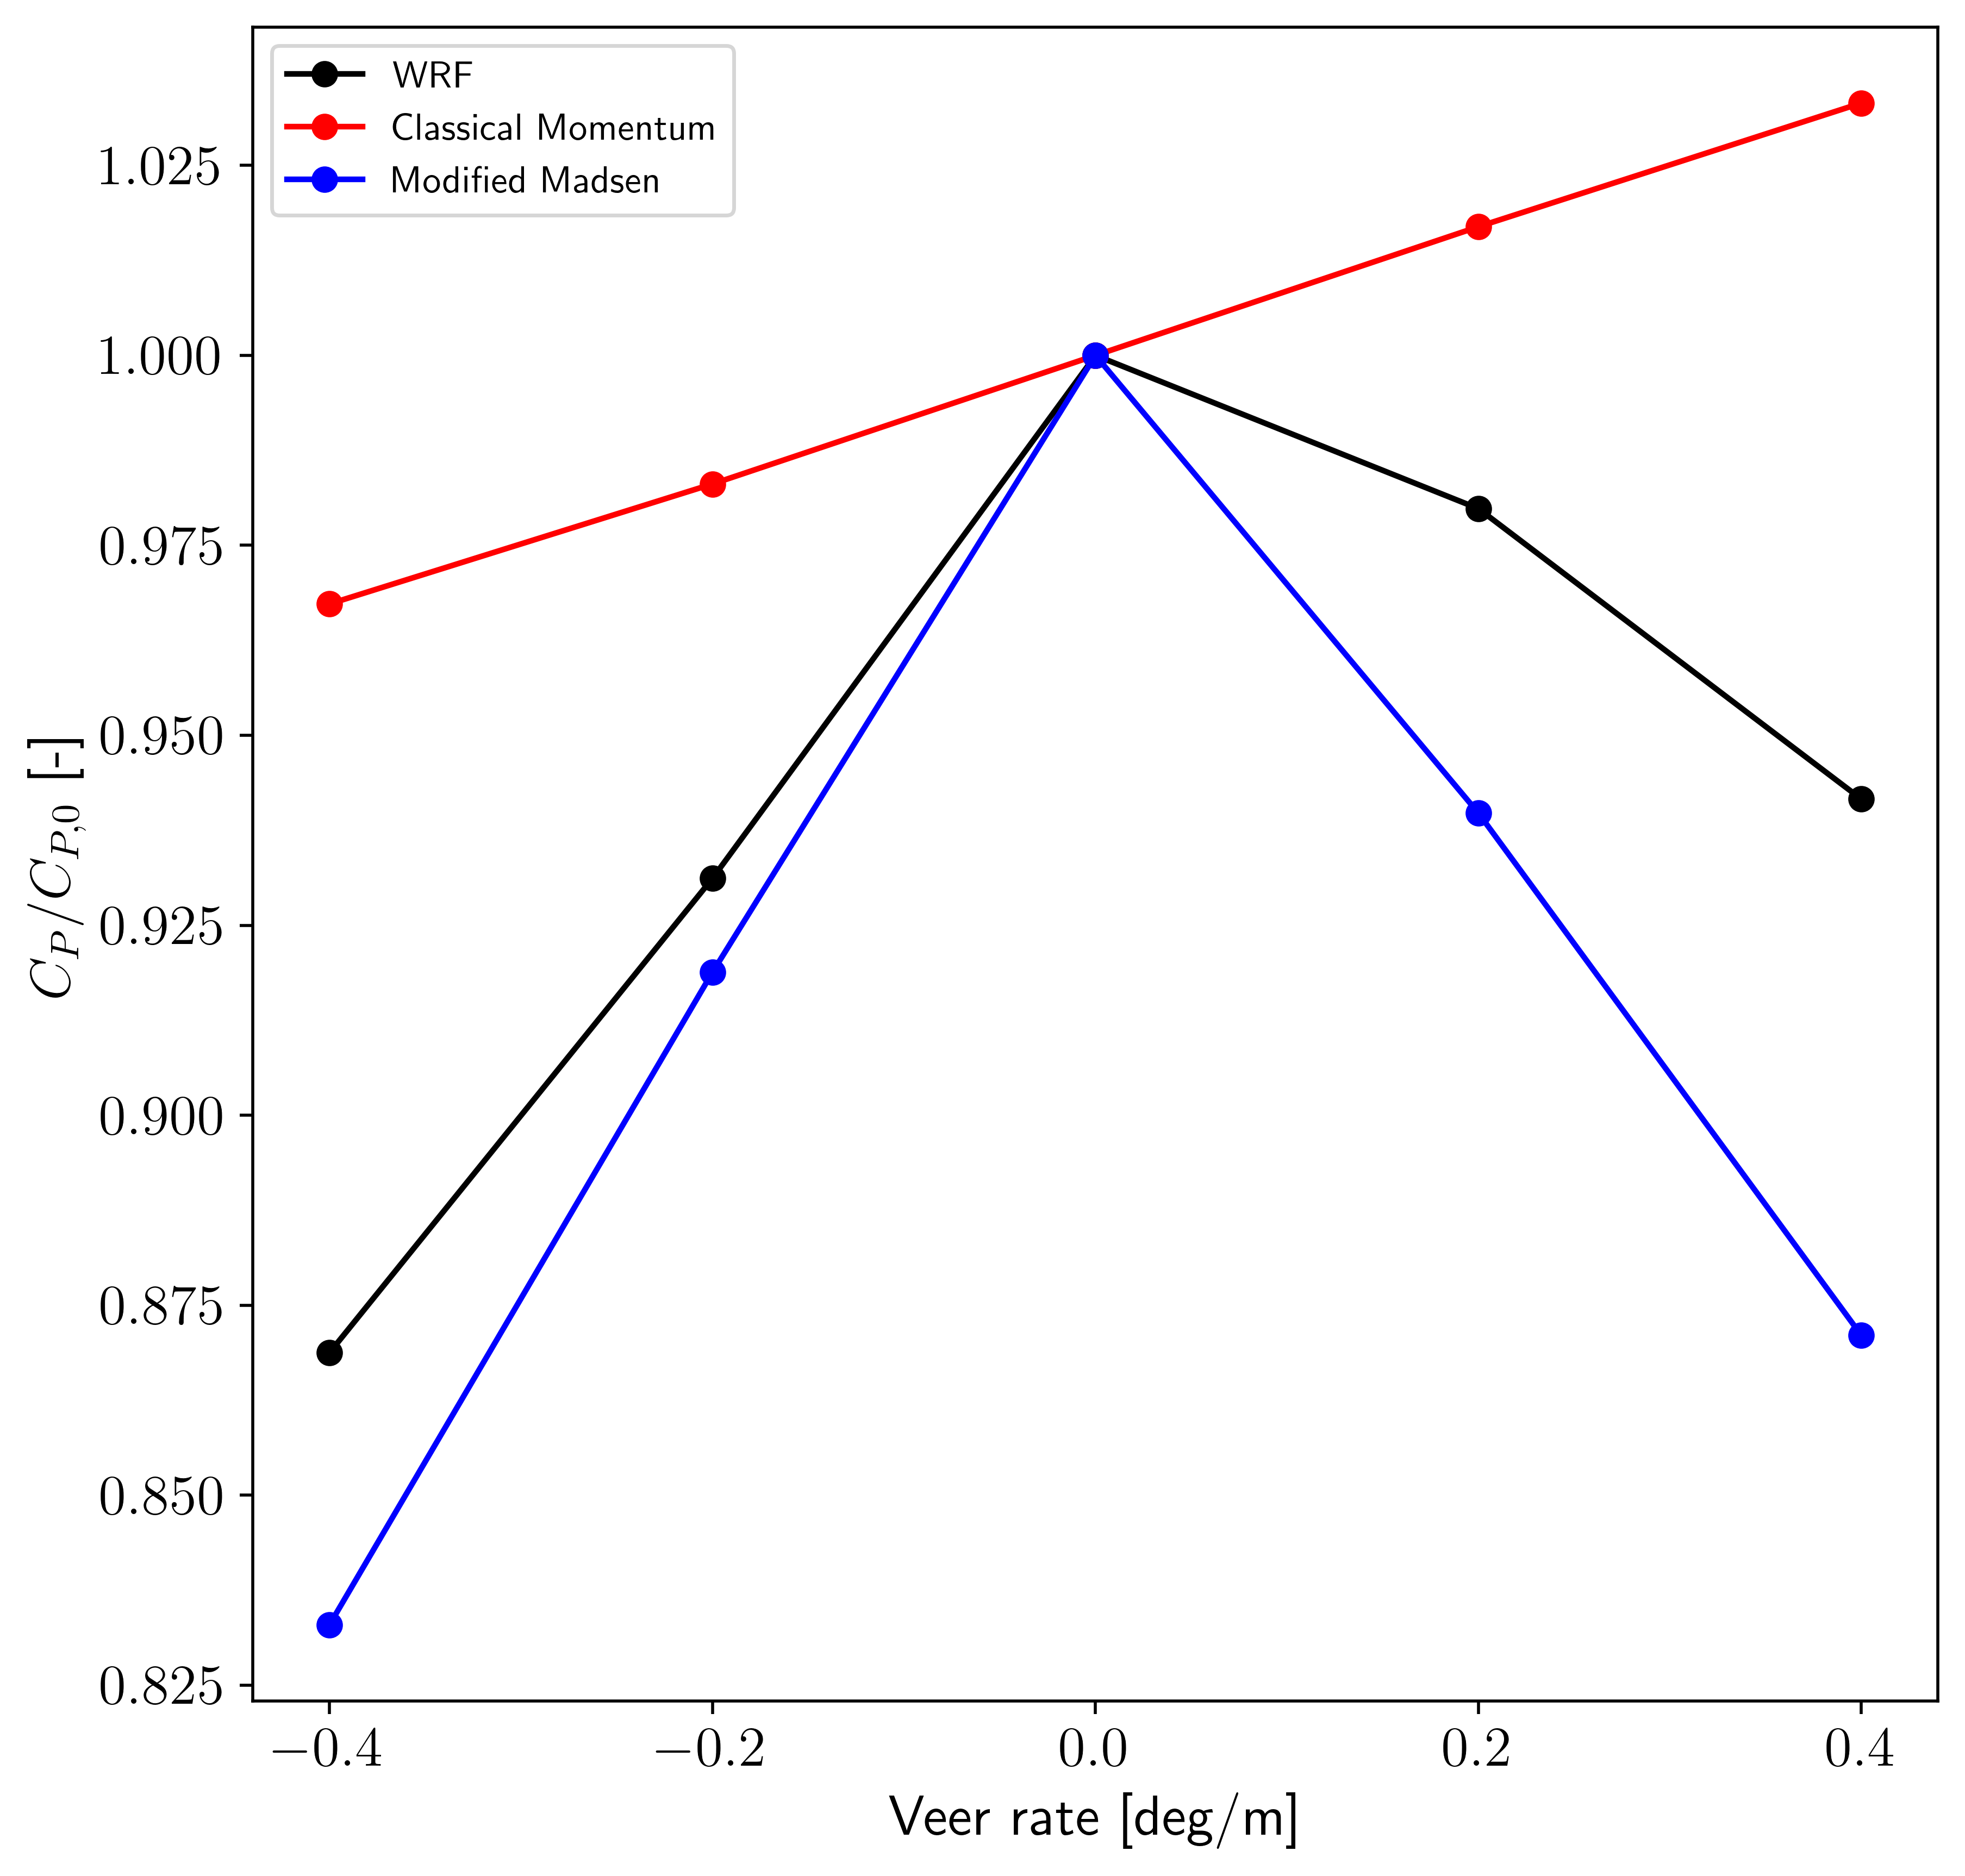

In [26]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(veers,cp[v_inds]/cp[6], 'o-k', label='WRF')
ax.plot(veers,classical[v_inds]/classical[6], 'o-r', label='Classical Momentum')
ax.plot(veers,madsen[v_inds]/madsen[6], 'o-b', label='Modified Madsen')

ax.set_xticks(veers)

# ax.set_ylim([0.40, 0.60])
ax.set_ylabel('$C_P / C_{P,0}$ [-]', fontsize=15)
ax.set_xlabel('Veer rate [deg/m]', fontsize=15)

ax.legend()

In [27]:
# madsen = np.array([0.45310412, 0.50074523, 0.49982093, 0.50016807, 0.54736666,
#        0.5449814 , 0.54397761, 0.54436565, 0.54615579, 0.51215169,
#        0.51120569, 0.51156072, 0.47381353])

madsen = np.array([0.34929321, 0.34985115, 0.35041895, 0.35099614, 0.3515793 ,
       0.35217182, 0.35276802, 0.35337203, 0.35397825, 0.3545911 ,
       0.35520693, 0.35582447, 0.3564442 , 0.35706586, 0.3576875 ,
       0.35830835, 0.35892832, 0.35954653, 0.36016216, 0.3607752 ,
       0.36138511, 0.36199012, 0.3625902 , 0.36318604, 0.36377687,
       0.36435955, 0.36493833, 0.36550874, 0.36607454, 0.36663124,
       0.36718164, 0.3677232 , 0.36825579])

# classical = np.array([0.50082847, 0.50987928, 0.50900215, 0.50942007, 0.52086116,
#        0.5186582 , 0.51776236, 0.51818118, 0.51992354, 0.52744682,
#        0.52653228, 0.52695186, 0.53495949])

classical = np.array([0.364247  , 0.36494489, 0.36565479, 0.36637729, 0.3671079 ,
       0.36785115, 0.36859965, 0.36935795, 0.37012121, 0.37089361,
       0.37167128, 0.37245333, 0.37323943, 0.3740296 , 0.37482121,
       0.37561413, 0.37640797, 0.37720139, 0.37799371, 0.37878494,
       0.37957548, 0.38036154, 0.38114321, 0.38192192, 0.38269698,
       0.3834634 , 0.38422688, 0.38498289, 0.38573463, 0.38647713,
       0.3872135 , 0.38794041, 0.38865898])

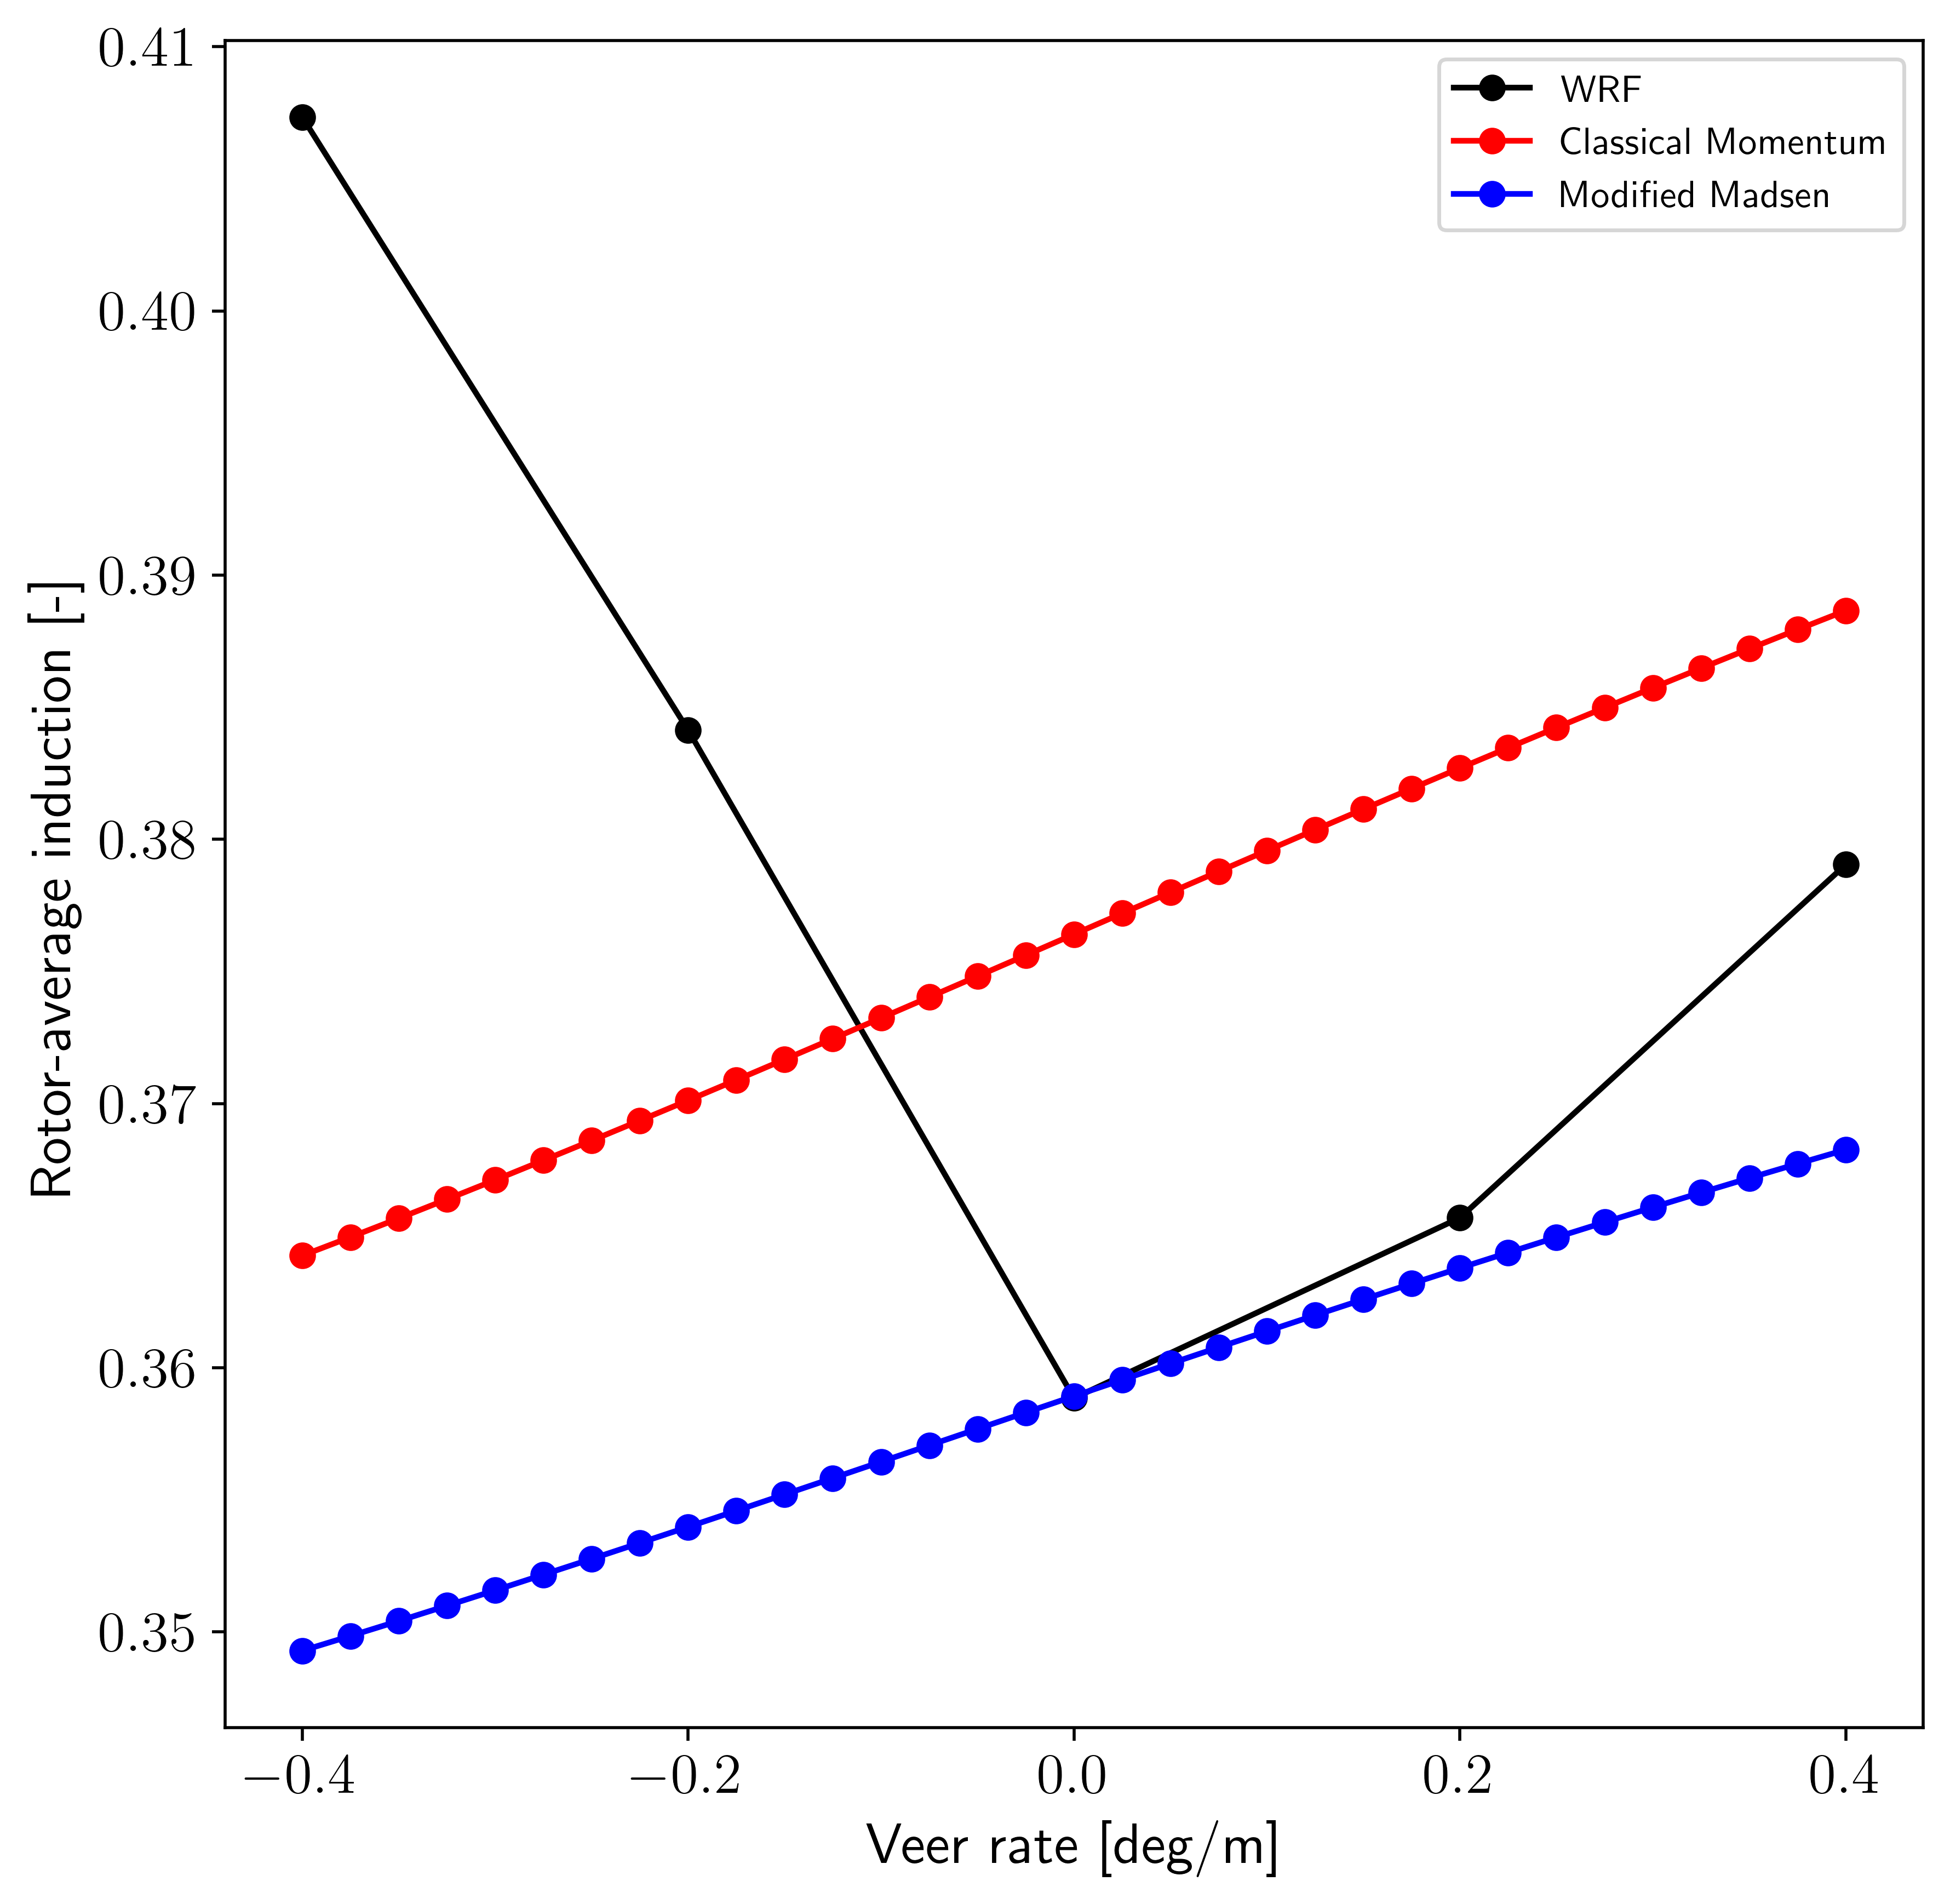

In [28]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(veers,induction[v_inds], 'o-k', label='WRF')
# ax.plot(veers,classical[v_inds], 'o-r', label='Classical Momentum')
ax.plot(veers_mit,classical, 'o-r', label='Classical Momentum',zorder=3)

# ax.plot(veers,madsen[v_inds], 'o-b', label='Modified Madsen')
ax.plot(veers_mit,madsen, 'o-b', label='Modified Madsen')


ax.set_xticks(veers)

# ax.set_ylim([0.40, 0.60])
ax.set_ylabel('Rotor-average induction [-]', fontsize=15)
ax.set_xlabel('Veer rate [deg/m]', fontsize=15)

ax.legend()

In [10]:
v_inds = [0,2,6,10,12]

power[v_inds]

array([2701426.25, 2911367.25, 3139348.25, 3066861.75, 2930200.5 ])

In [12]:
induction[v_inds]

array([0.40733797, 0.3841373 , 0.35885413, 0.36567665, 0.37904797])